[https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success)

In [1]:
from ucimlrepo import fetch_ucirepo 

In [2]:
# fetch dataset 
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697) 
  
# data (as pandas dataframes) 
X = predict_students_dropout_and_academic_success.data.features 
y = predict_students_dropout_and_academic_success.data.targets

In [3]:
# metadata 
print(predict_students_dropout_and_academic_success.metadata.keys()) 

print('\n'+predict_students_dropout_and_academic_success.metadata['abstract']+'\n')
print('missing values:', predict_students_dropout_and_academic_success.metadata['has_missing_values']+'\n') 
print(predict_students_dropout_and_academic_success.metadata['additional_info']['recommended_data_splits']+'\n') 
print(predict_students_dropout_and_academic_success.metadata['additional_info']['instances_represent']+'\n') 
print(predict_students_dropout_and_academic_success.metadata['additional_info']['citation']+'\n')
print(predict_students_dropout_and_academic_success.metadata['creators']) 

dict_keys(['uci_id', 'name', 'repository_url', 'data_url', 'abstract', 'area', 'tasks', 'characteristics', 'num_instances', 'num_features', 'feature_types', 'demographics', 'target_col', 'index_col', 'has_missing_values', 'missing_values_symbol', 'year_of_dataset_creation', 'last_updated', 'dataset_doi', 'creators', 'intro_paper', 'additional_info'])

A dataset created from a higher education institution (acquired from several disjoint databases) related to students enrolled in different undergraduate degrees, such as agronomy, design, education, nursing, journalism, management, social service, and technologies.
The dataset includes information known at the time of student enrollment (academic path, demographics, and social-economic factors) and the students' academic performance at the end of the first and second semesters. 
The data is used to build classification models to predict students' dropout and academic sucess. The problem is formulated as a three category classification tas

---

### **Descripción**

Un conjunto de datos creado a partir de una institución de educación superior (integrado desde varias bases de datos independientes) que contiene información de estudiantes inscritos en distintas licenciaturas, como agronomía, diseño, educación, enfermería, periodismo, administración, trabajo social y tecnologías.

El dataset incluye información conocida en el momento de la inscripción del estudiante (trayectoria académica previa, datos demográficos y factores socioeconómicos), así como su desempeño académico al finalizar el primer y segundo semestre.

Los datos se utilizan para construir modelos de clasificación que predicen el abandono escolar (*dropout*) y el éxito académico de los estudiantes. El problema se plantea como una tarea de clasificación con tres categorías, en la cual existe un fuerte desbalance hacia una de las clases.

---

### **Autores**

* Valentim Realinho
* Mónica Vieira Martins
* Jorge Machado
* Luís Baptista

---

### **Cita**

M.V.Martins, D. Tolledo, J. Machado, L. M.T. Baptista, V.Realinho. (2021) "Early prediction of student’s performance in higher education: a case study" Trends and Applications in Information Systems and Technologies, vol.1, in Advances in Intelligent Systems and Computing series. Springer. DOI: 10.1007/978-3-030-72657-7_16

---

In [4]:
# variable information 
description = predict_students_dropout_and_academic_success.variables
display(description)

,name,role,type,demographic,description,units,missing_values
0,Marital Status,Feature,Integer,Marital Status,1 – single 2 – married 3 – widower 4 – divorce...,None,no
1,Application mode,Feature,Integer,None,1 - 1st phase - general contingent 2 - Ordinan...,None,no
2,Application order,Feature,Integer,None,Application order (between 0 - first choice; a...,None,no
3,Course,Feature,Integer,None,33 - Biofuel Production Technologies 171 - Ani...,None,no
4,Daytime/evening attendance,Feature,Integer,None,1 – daytime 0 - evening,None,no
5,Previous qualification,Feature,Integer,Education Level,1 - Secondary education 2 - Higher education -...,None,no
6,Previous qualification (grade),Feature,Continuous,None,Grade of previous qualification (between 0 and...,None,no
7,Nacionality,Feature,Integer,Nationality,1 - Portuguese; 2 - German; 6 - Spanish; 11 - ...,None,no
8,Mother's qualification,Feature,Integer,Education Level,1 - Secondary Education - 12th Year of Schooli...,None,no
9,Father's qualification,Feature,Integer,Education Level,1 - Secondary Education - 12th Year of Schooli...,None,no


# Bibliotecas

In [5]:
# Sistema
import os

# Análisis y manipulación de datos
import numpy as np
import pandas as pd

from scipy.stats import uniform

# Manejo de texto plano
import re
import emoji
import unicodedata

# Nube de palabras
from wordcloud import WordCloud, STOPWORDS

# Análisis de texto
import spacy
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Modelo de regresión logítica y Bayes
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Búsqueda de hiper-parámetros, train test, métricas
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, roc_curve, confusion_matrix, make_scorer, mean_squared_error, mean_absolute_error
from sklearn.svm import LinearSVC, SVR

# Guardar modelo y pipeline
import pickle
from sklearn.pipeline import make_pipeline

#Graficas

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from pandas.plotting import andrews_curves

# Funciones

In [6]:
def is_na_df(df):
    #Establecemos el resumen de NAs por columna
    na_summary = (
        df.isna().sum()
        .reset_index()
        .rename(columns={"index": "columna", 0: "n_missing"})
    )

    #Tomamos totales y prporciones
    na_summary["total"] = len(df)
    na_summary["prop_missing"] = na_summary["n_missing"] / na_summary["total"]
    na_summary["prop_original"] = 1 - na_summary["prop_missing"]

    #Filtramos solo columnas con al menos 1 NA
    na_summary = na_summary[na_summary["n_missing"] > 0].reset_index(drop=True)

    #Agregamos fila resumen global
    total_missing = df.isna().sum().sum()
    total_elements = df.size
    prop_missing_global = total_missing / total_elements
    prop_original_global = 1 - prop_missing_global

    resumen = pd.DataFrame({
        "columna": ["TOTAL"],
        "n_missing": [total_missing],
        "total": [total_elements],
        "prop_missing": [prop_missing_global],
        "prop_original": [prop_original_global]
    })

    na_summary = pd.concat([na_summary, resumen], ignore_index=True)

    return na_summary

In [7]:
#Definimos un objeto para graficar
class analyze:
    # Inicializamos la clase
    def __init__(self, df, num_vars, cat_vars):
        self.df = df
        self.num_vars = num_vars
        self.cat_vars = cat_vars

    #Método para graficar variables numéricas
    def plot_num(self):
        for var in self.num_vars:
            fig = make_subplots(rows=1, cols=2)

            # Boxplot
            fig.add_trace(
                go.Box(y=self.df[var], name="Boxplot", marker_color="#de3163"),
                row=1, col=1
            )

            # Histograma
            fig.add_trace(
                go.Histogram(x=self.df[var], name="Histograma",
                             marker_color="#31deac", nbinsx=50,
                             histnorm='probability density'),
                row=1, col=2
            )

            fig.update_layout(title_text=f"Variable: {var}", height=400, width=800)
            fig.show()

    #Método para graficar variables categóricas
    def plot_cat(self):
        for var in self.cat_vars:
            value_counts = self.df[var].value_counts()
            labels = value_counts.index.astype(str)
            values = value_counts.values

            fig = go.Figure(
                data=[go.Pie(labels=labels, values=values,textinfo='label+value+percent',
                    marker=dict(colors=["#de3163", "#31deac"])
                                )
                    ]
            )

            fig.update_layout(title_text=f"Variable: {var}", height=400, width=500)
            fig.show()

    #Método para graficar la matriz de correlación de numéricas
    def corr_matrix(self):
        corr_matrix = self.df[self.num_vars].corr()

        fig = go.Figure(data=go.Heatmap(
            z=corr_matrix.values,
            x=corr_matrix.columns,
            y=corr_matrix.columns,
            colorscale='Inferno'))

        fig.update_layout(
            title='Matriz de Correlación',
            width=800,
            height=600
        )

        fig.show()

# EDA

## Dataset

In [8]:
students = pd.concat([X, y], axis=1)

In [9]:
students.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [10]:
students.shape

(4424, 37)

In [11]:
is_na_df(students)

,columna,n_missing,total,prop_missing,prop_original
0,TOTAL,0,163688,0.0,1.0


## Definición de variables

In [12]:
var_cat = students.select_dtypes('object').columns.tolist() + [x for x in students.columns if students[x].unique().__len__() < 10]

In [13]:
var_num = [x for x in students.columns if x not in var_cat]

## Distribución de variables

In [14]:
analisis_students = analyze(students, var_num, var_cat)

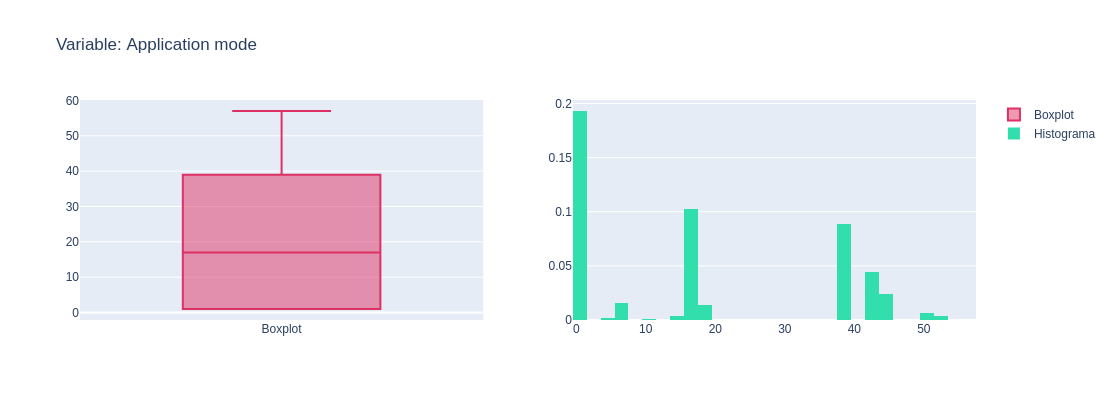

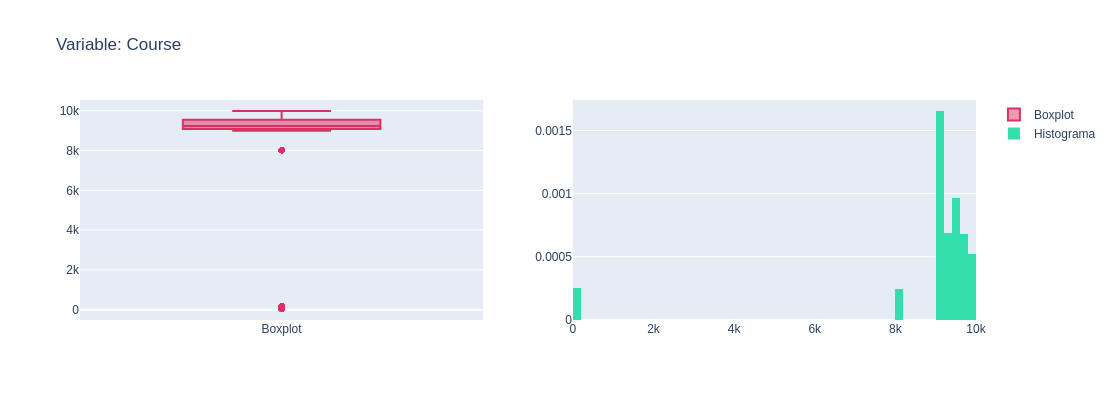

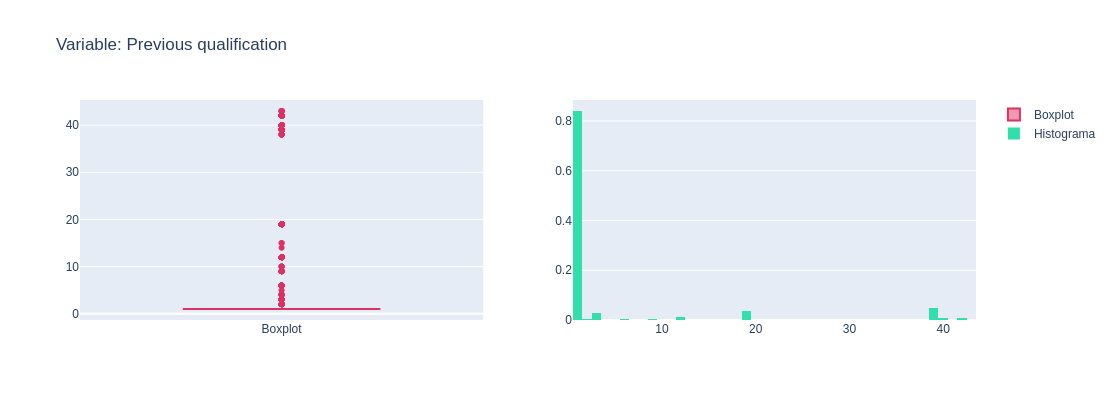

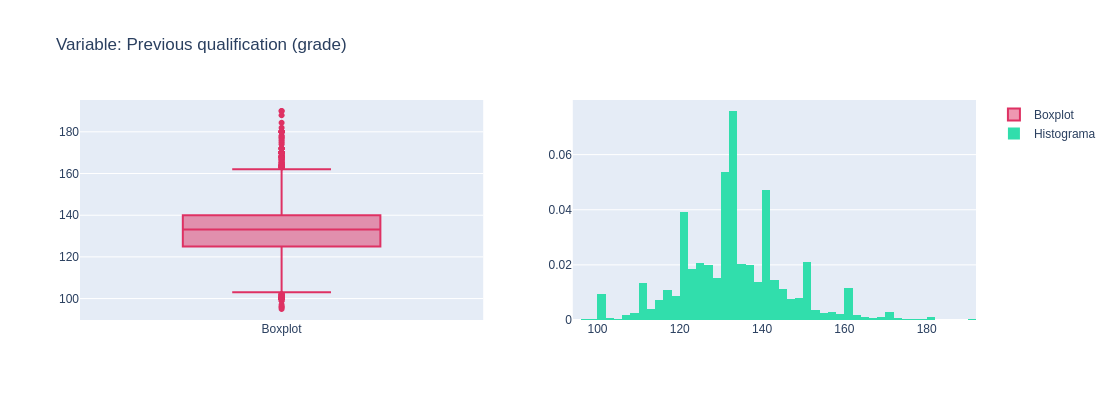

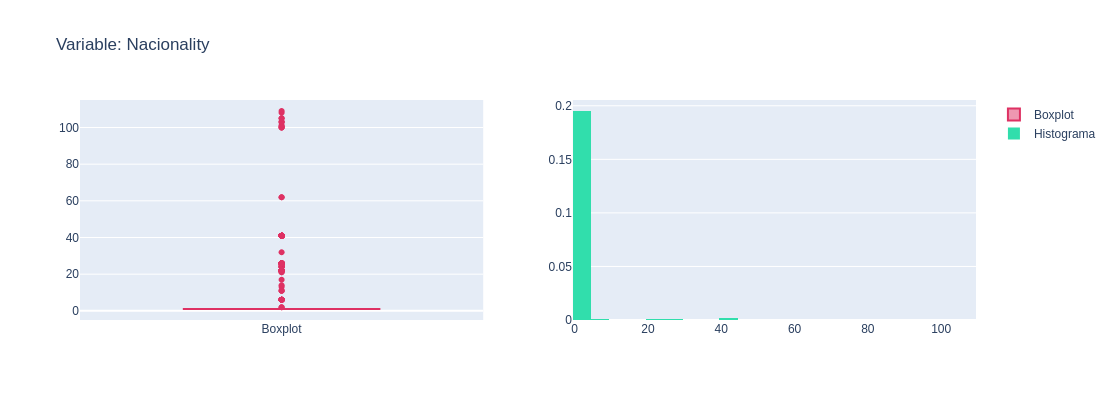

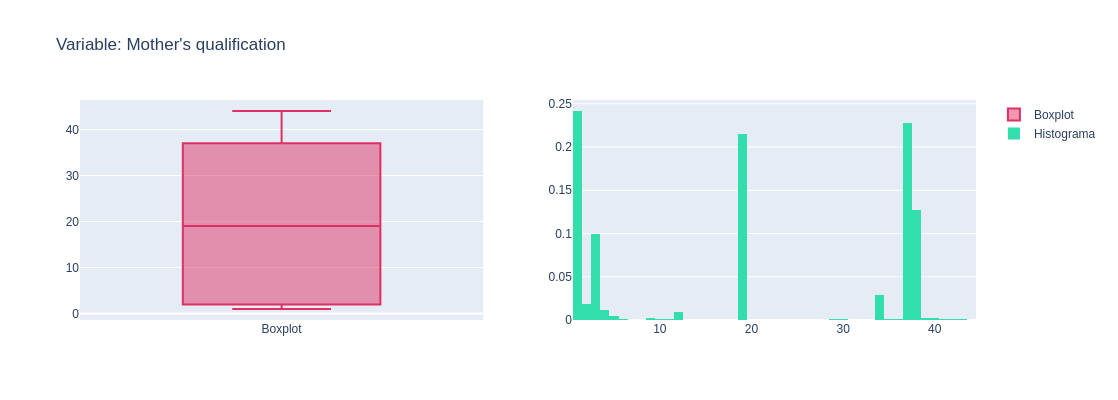

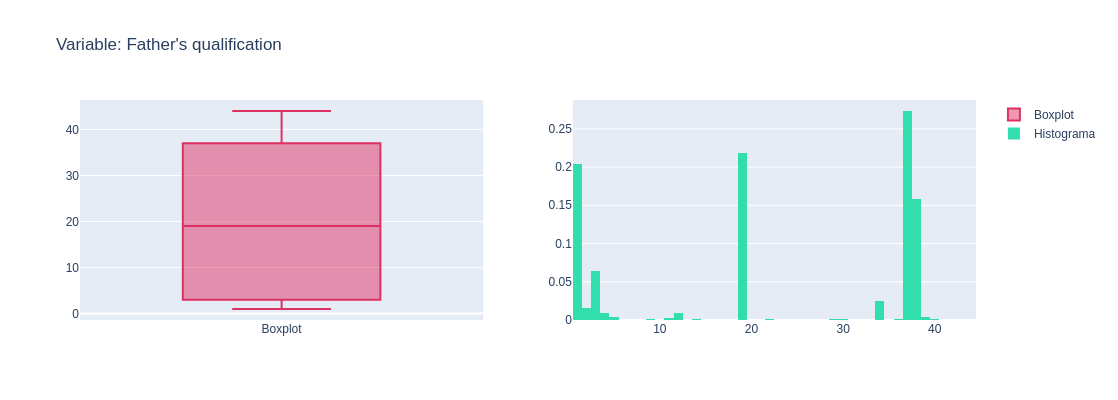

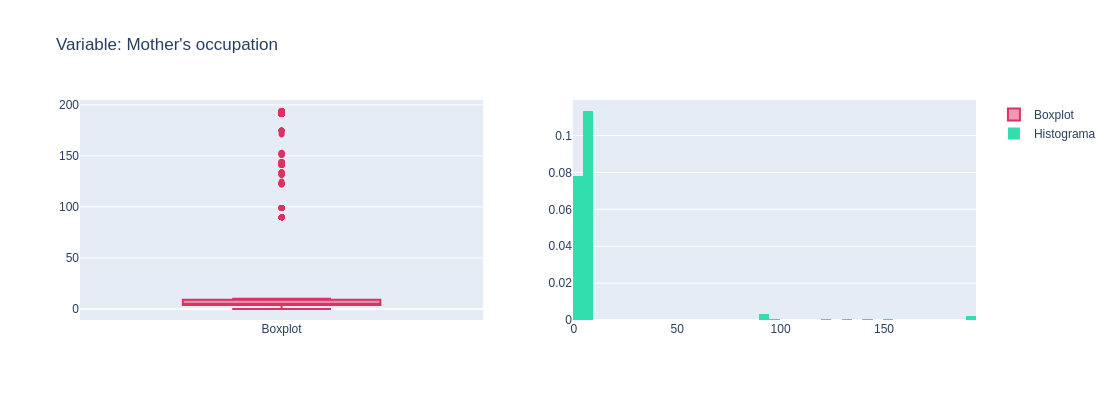

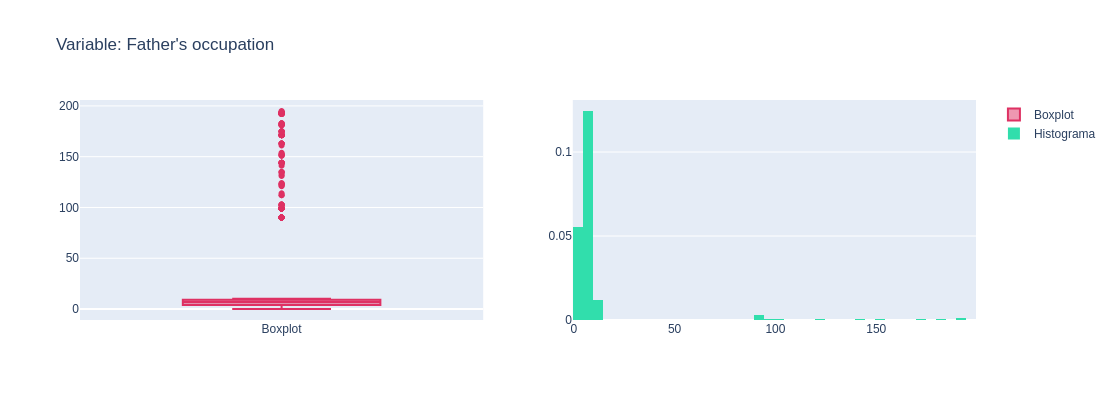

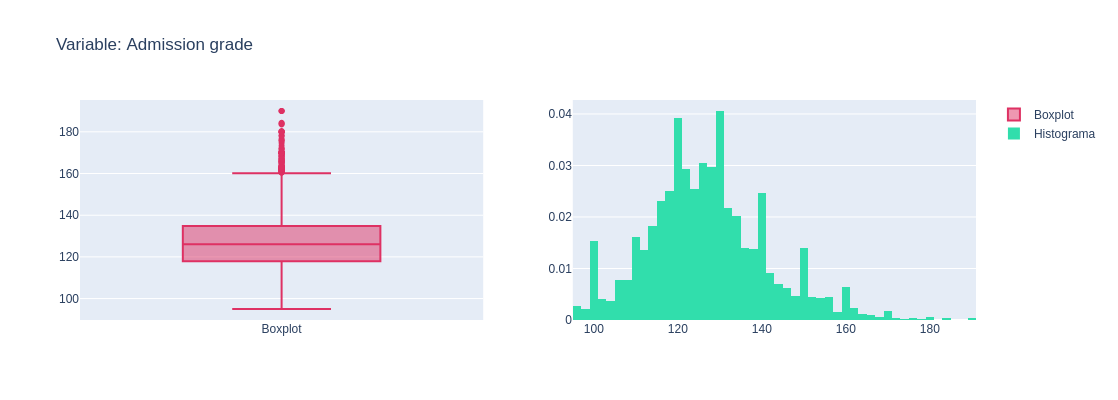

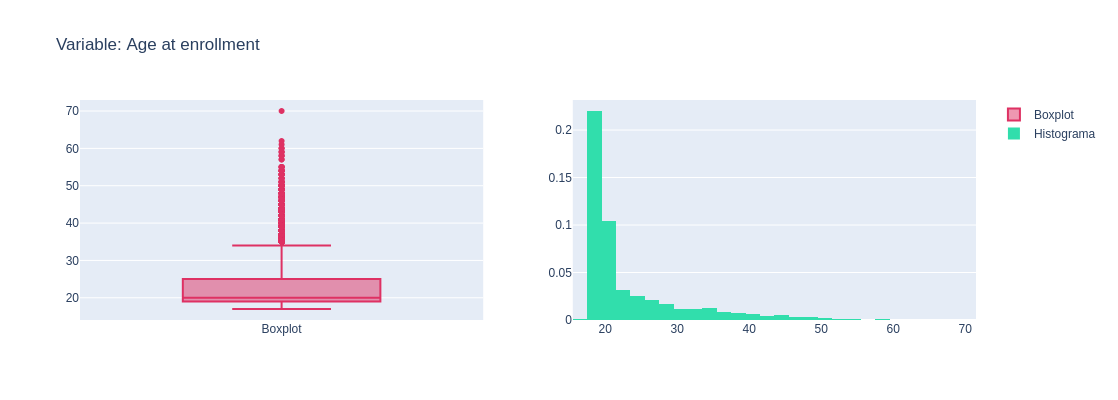

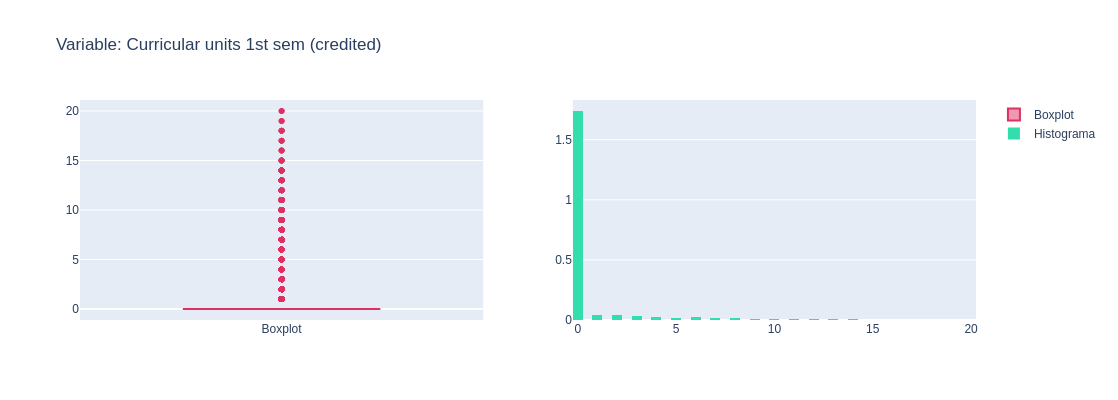

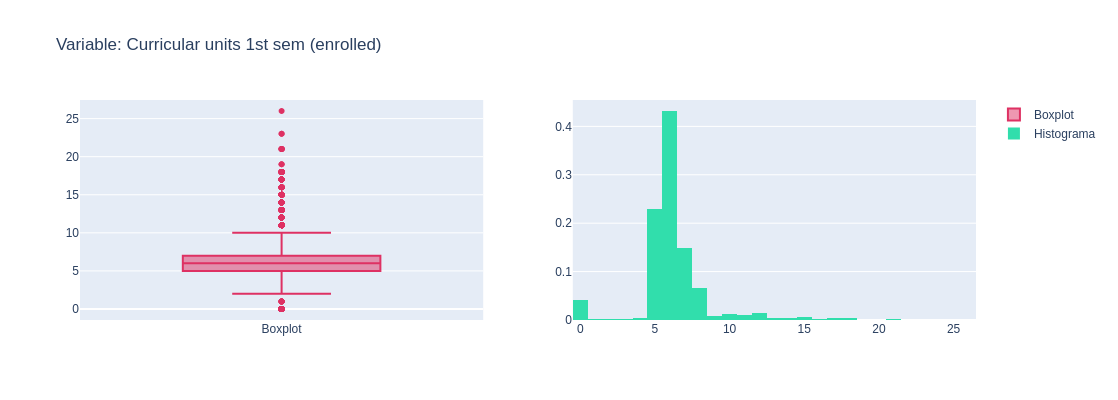

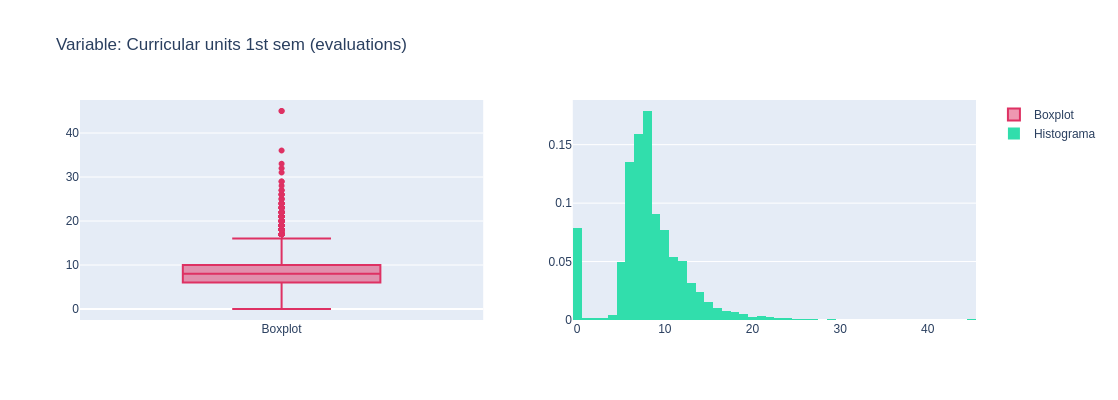

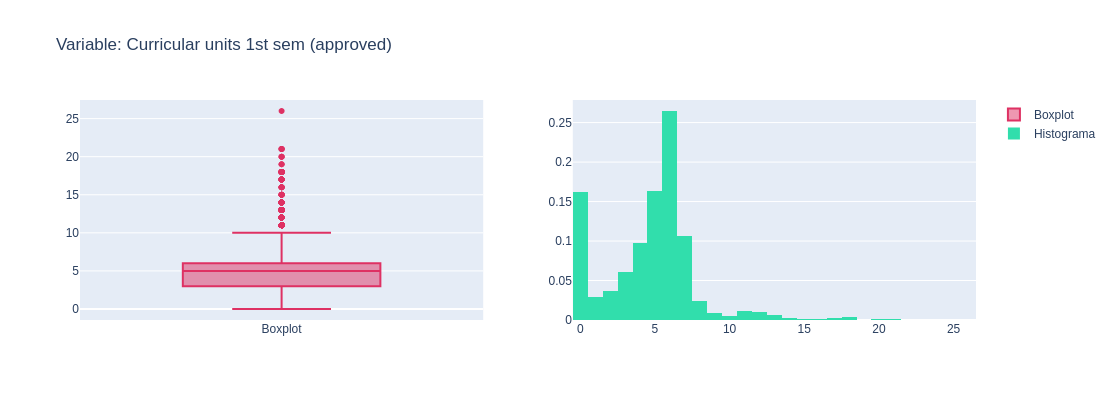

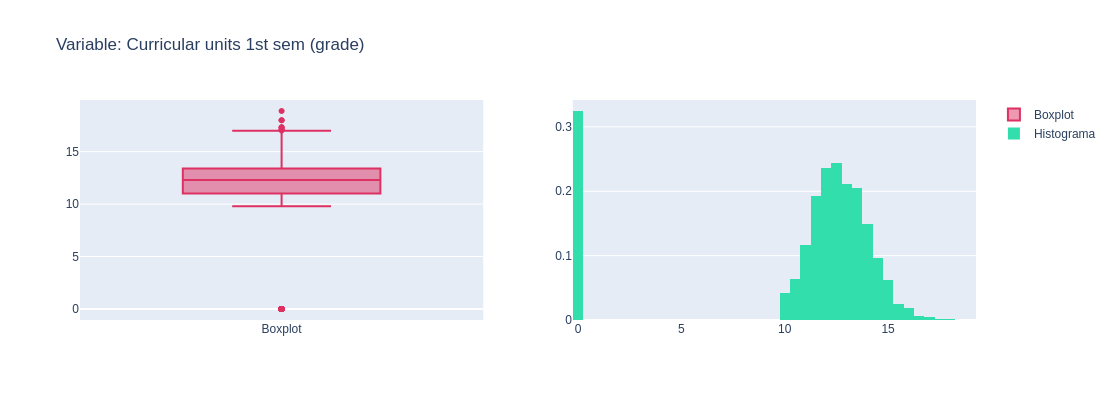

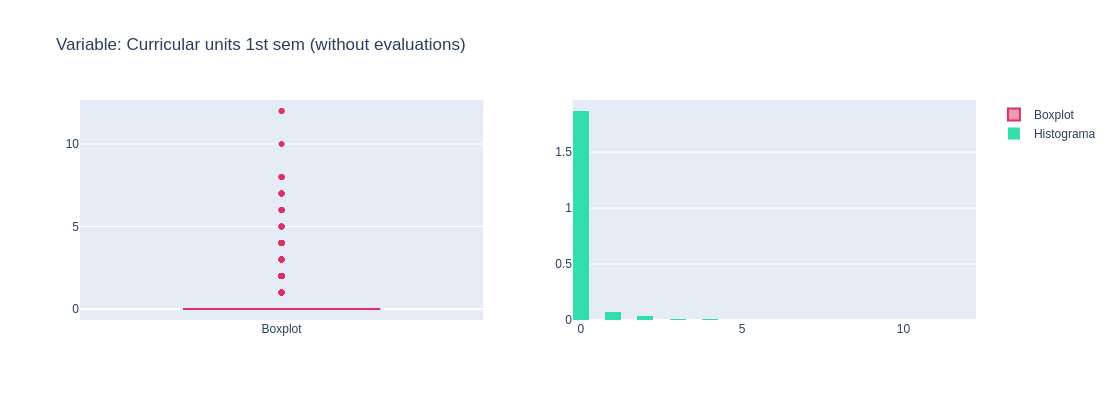

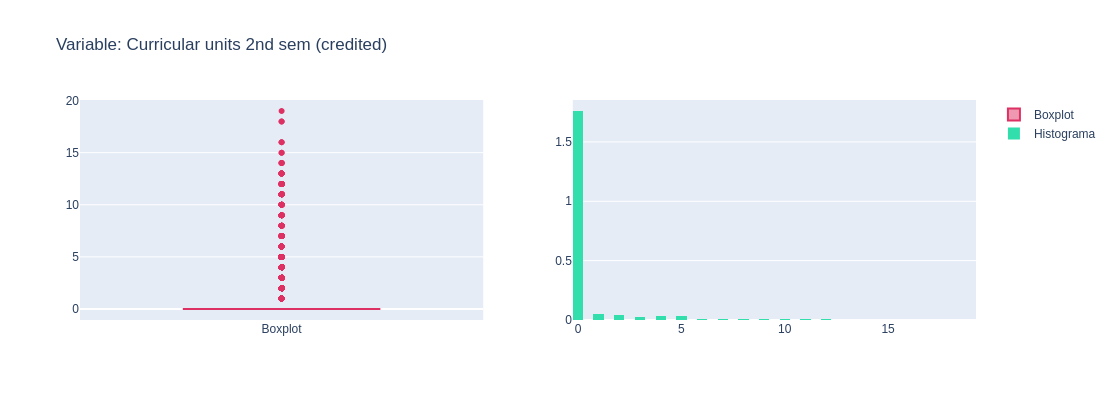

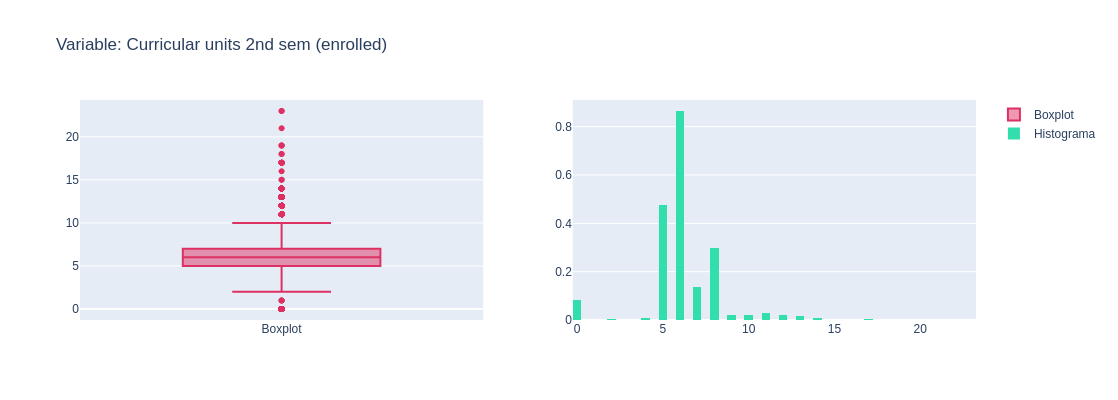

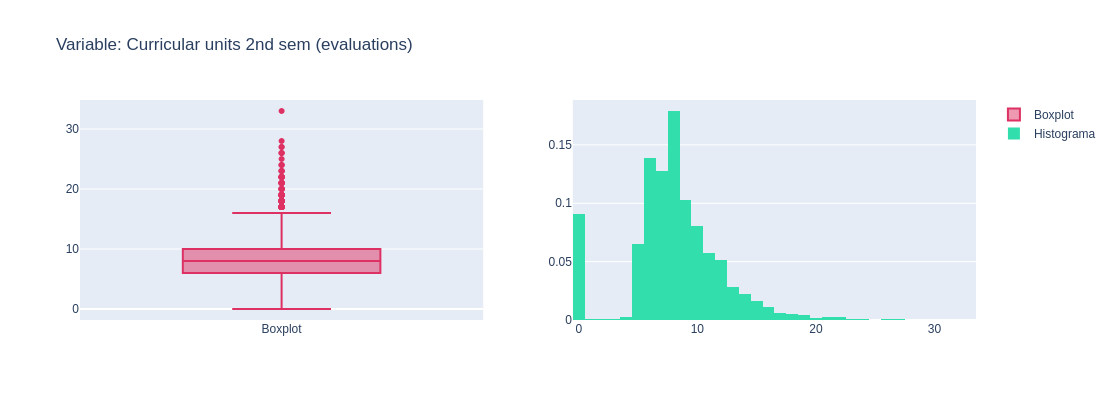

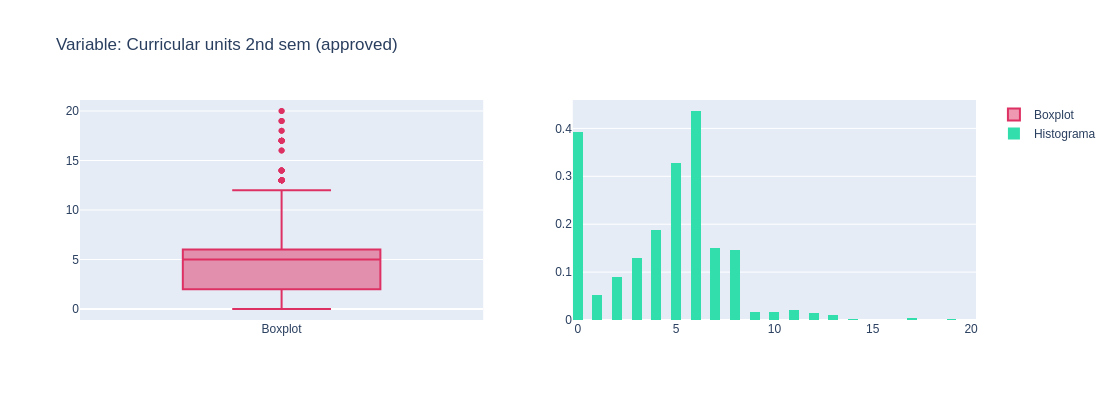

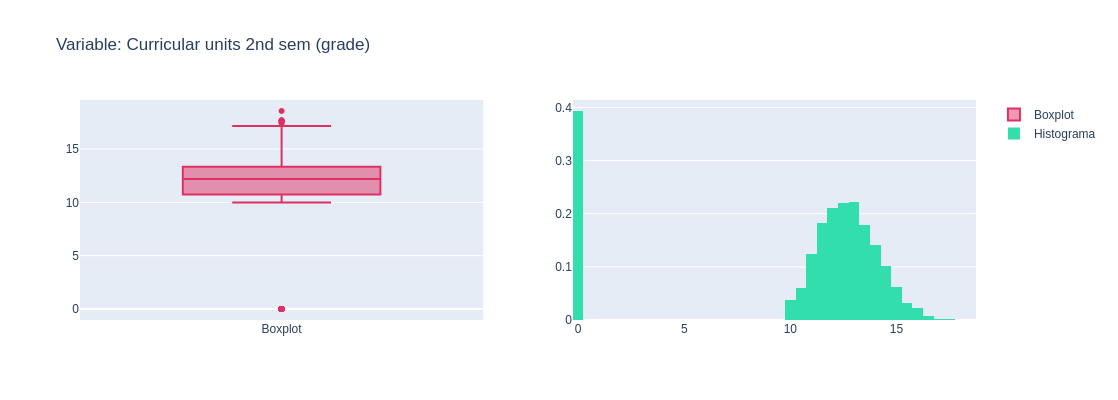

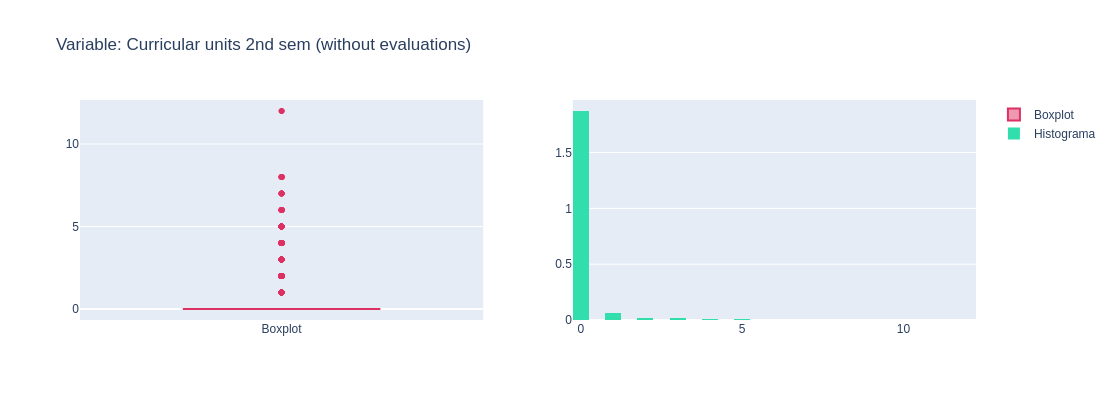

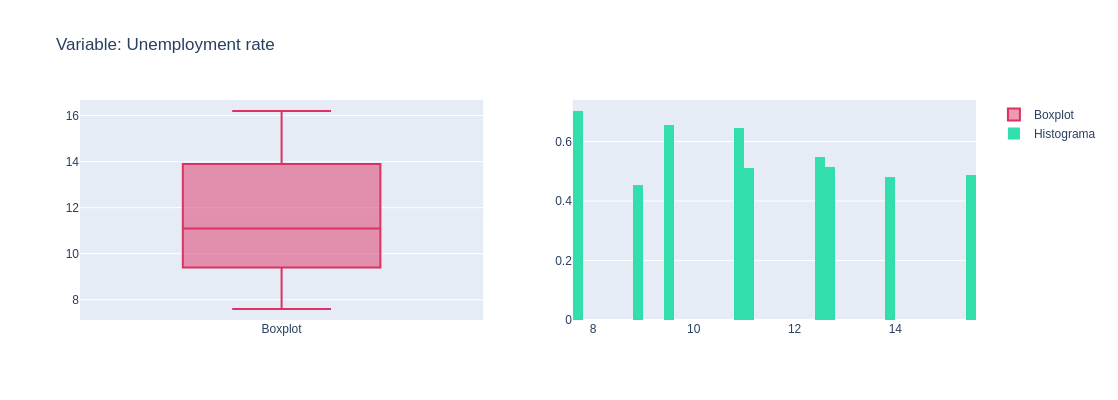

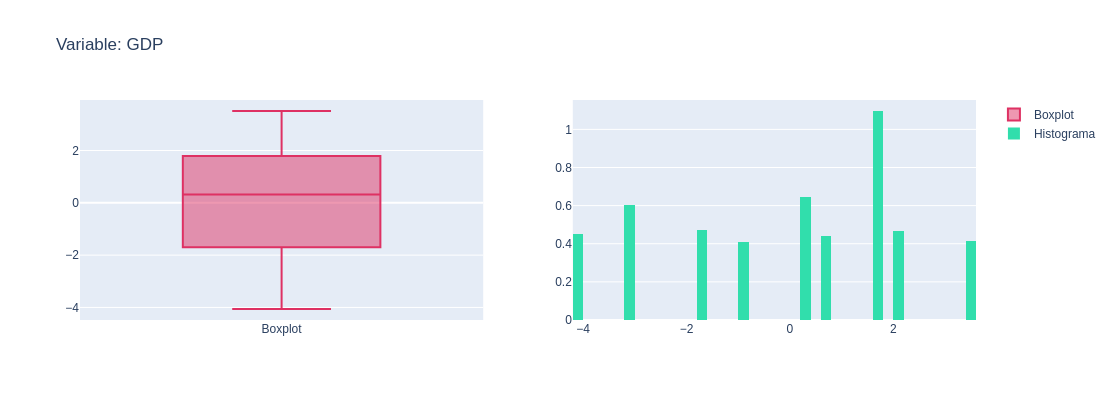

In [15]:
analisis_students.plot_num()

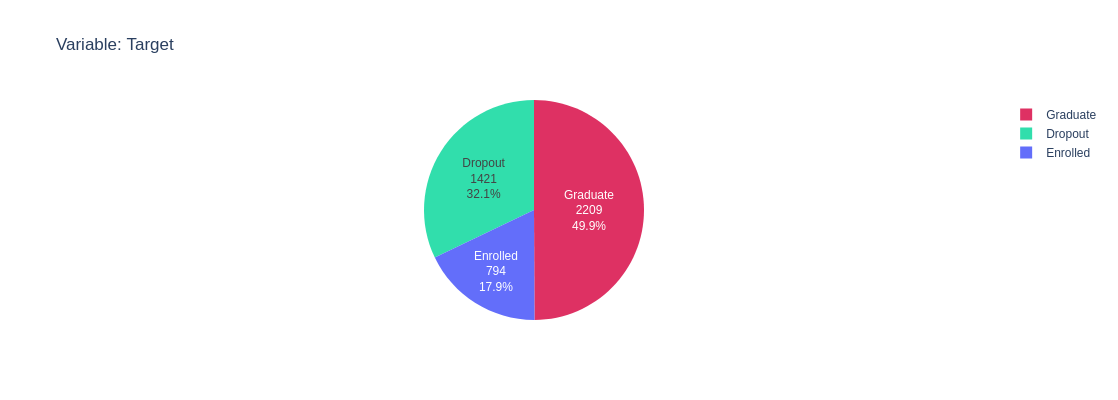

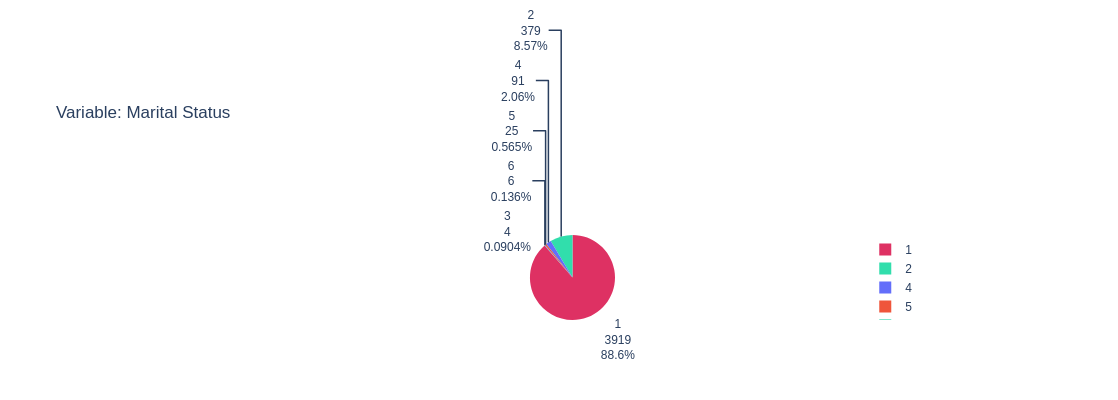

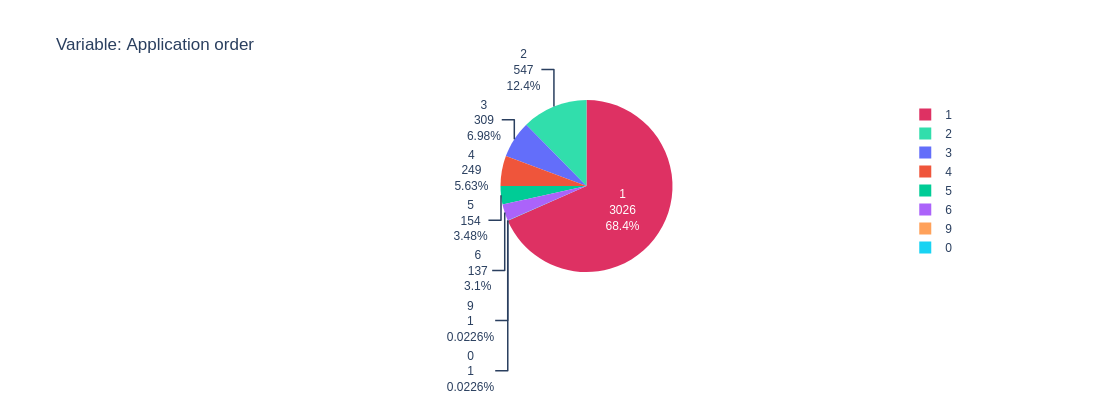

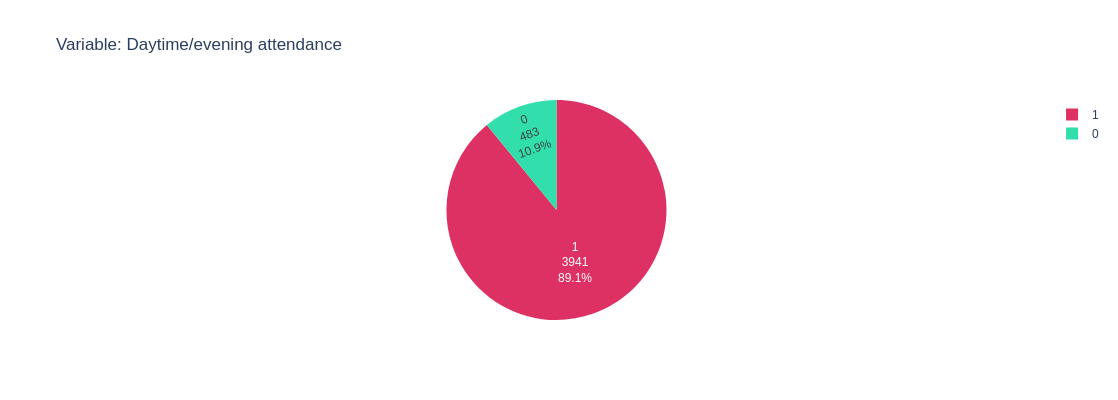

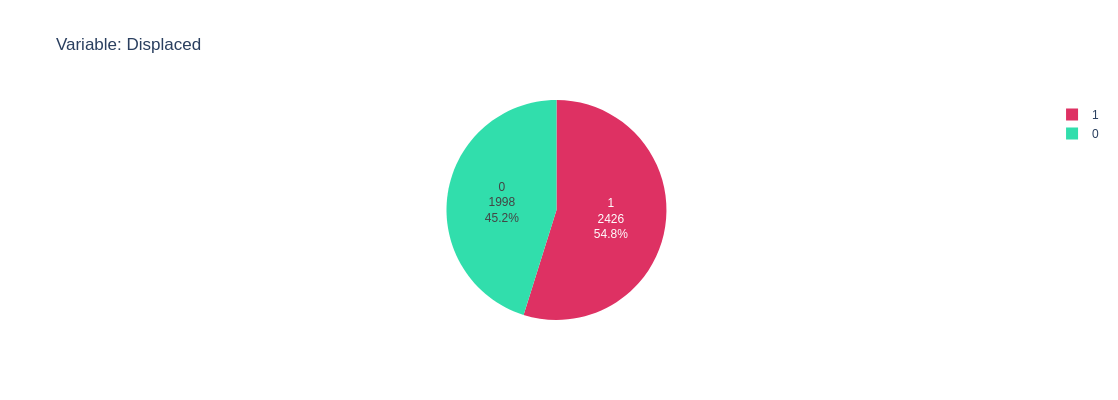

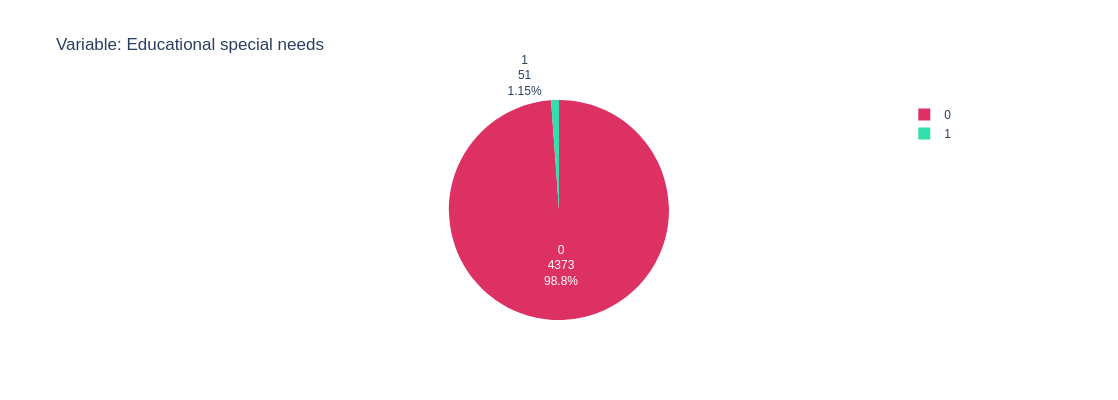

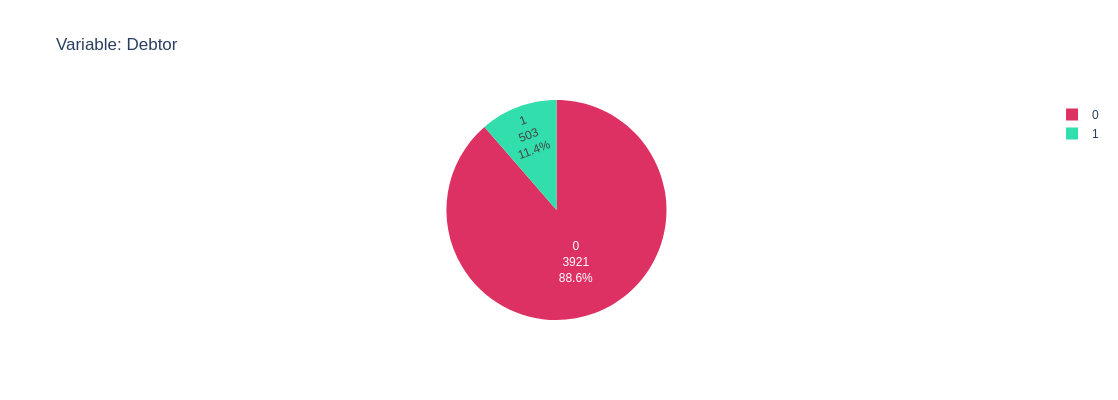

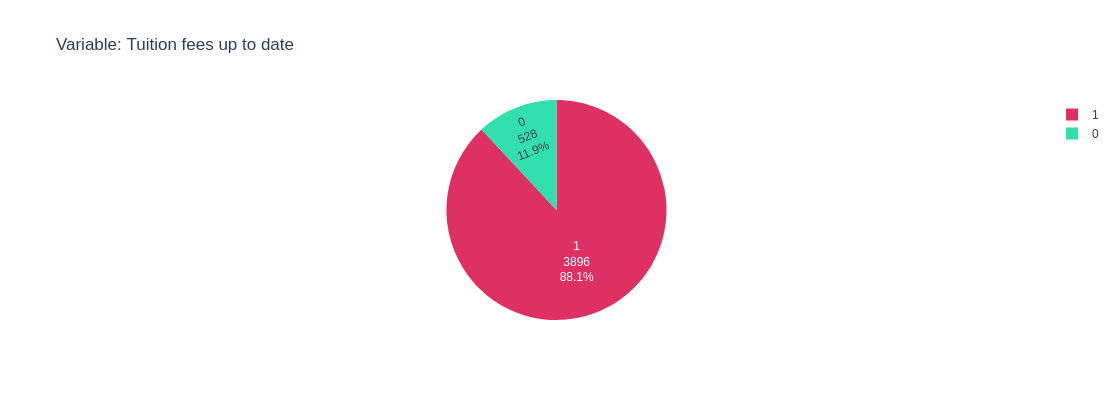

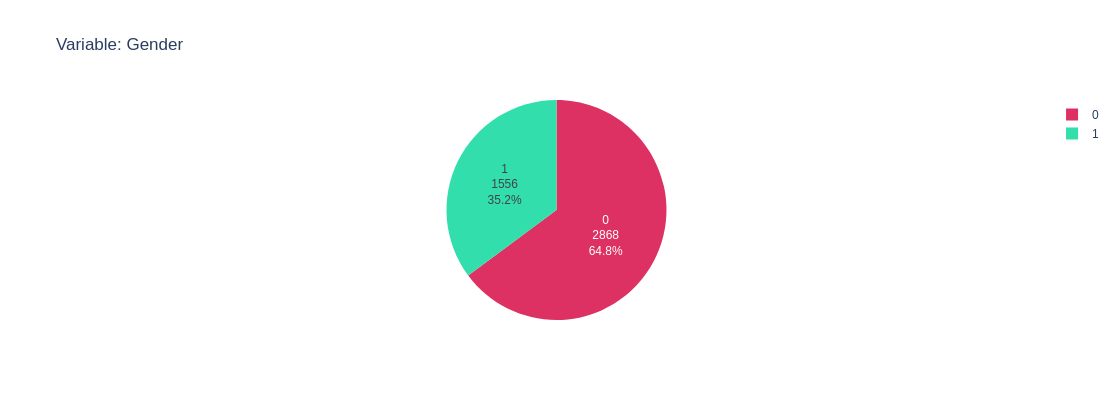

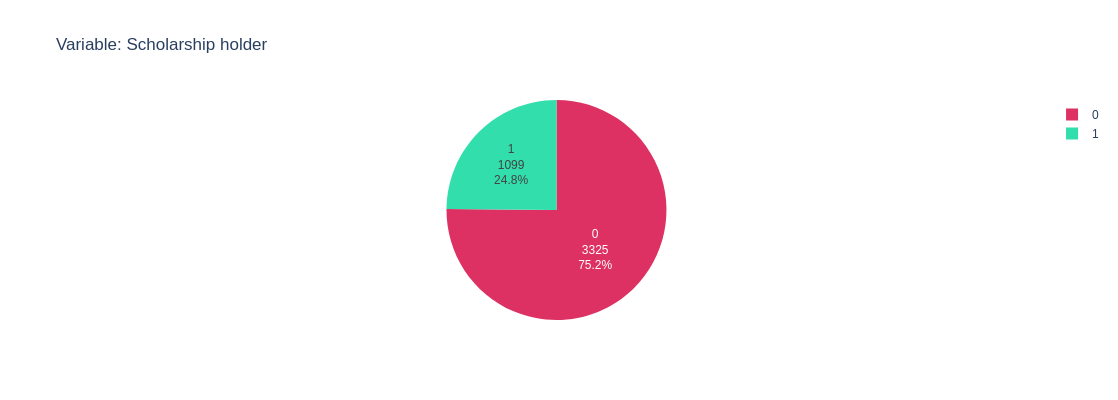

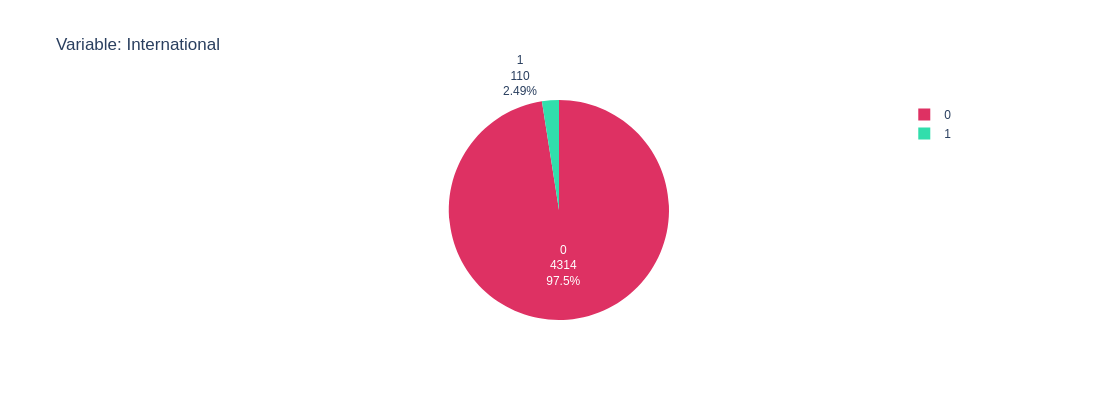

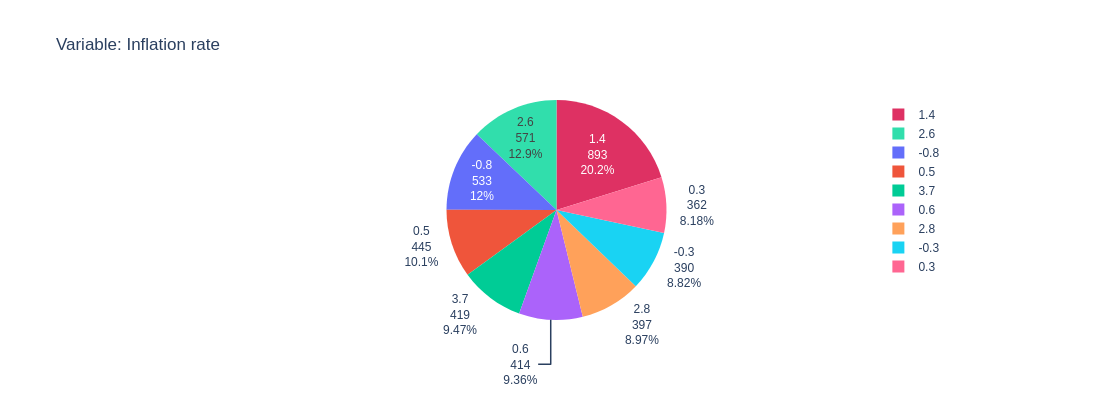

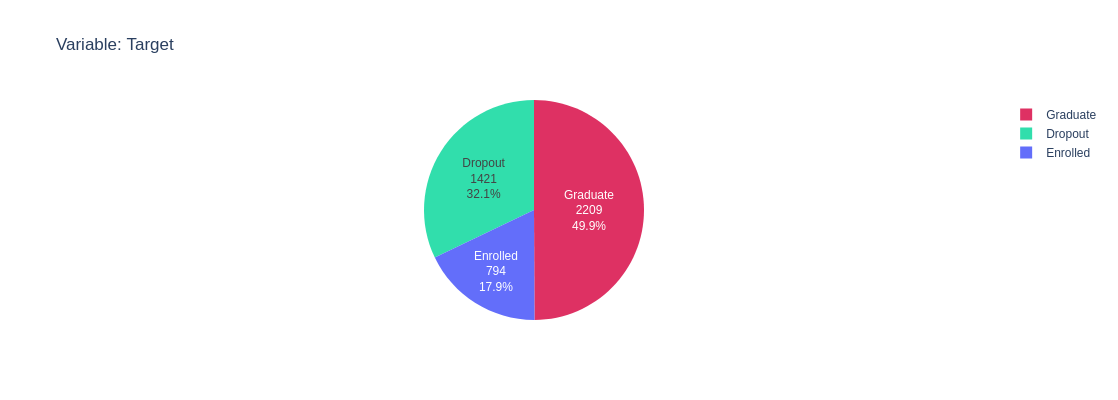

In [16]:
analisis_students.plot_cat()

Variables categóricas desbalanceadas
* Daytime / evening attendance
* Educational special needs
* Debtor (could go)
* Tuition fees up to date (could go)
* International

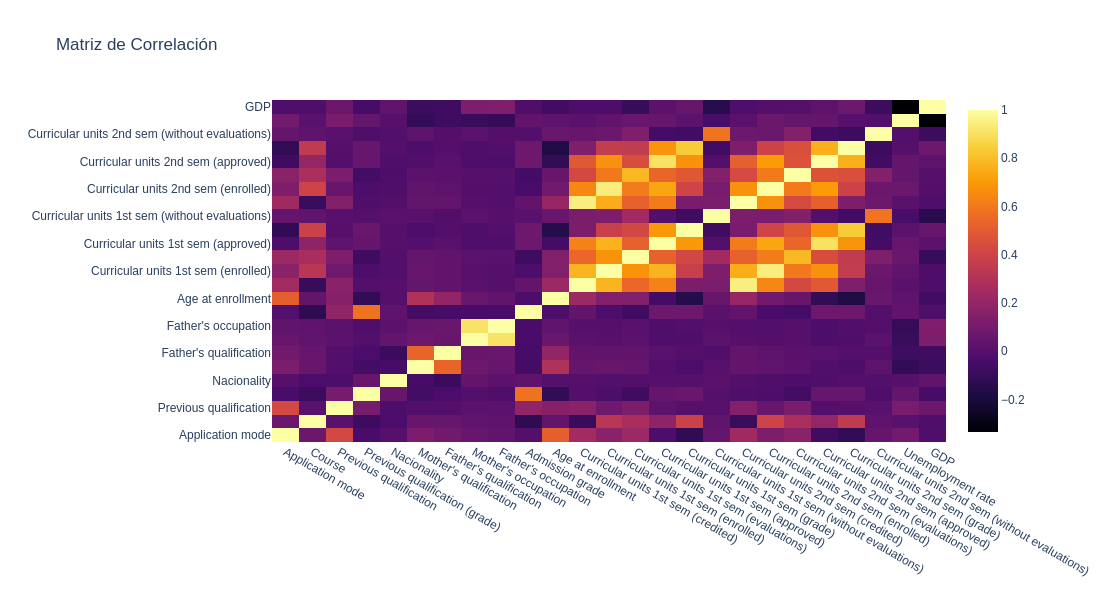

In [17]:
analisis_students.corr_matrix()

In [18]:
def locf(field: str):
    global description
    return description.loc[description['name'] == field]['description'].iloc[0]

In [19]:
locf('Course')

'33 - Biofuel Production Technologies 171 - Animation and Multimedia Design 8014 - Social Service (evening attendance) 9003 - Agronomy 9070 - Communication Design 9085 - Veterinary Nursing 9119 - Informatics Engineering 9130 - Equinculture 9147 - Management 9238 - Social Service 9254 - Tourism 9500 - Nursing 9556 - Oral Hygiene 9670 - Advertising and Marketing Management 9773 - Journalism and Communication 9853 - Basic Education 9991 - Management (evening attendance)'

Jajaja sí, esa regex se ve medio monstruo al principio 😅
Vamos por partes, porque **cada pedacito hace algo muy específico**.

La expresión que usamos en `re.split` fue:

```python
r'(?<!\d)(?=\d+\s*-\s*)'
```

La idea general:
👉 *“Corta el texto en cualquier posición donde COMIENCE un número seguido de `-`, siempre y cuando antes no haya otro dígito.”*

Ahora sí, línea por línea:

---

### 1. `(?<!\d)` → *negative lookbehind*

* `(?<! … )` se llama **lookbehind negativo**.
* Traducción: *“en esta posición, asegúrate de que justo antes NO haya algo que cumpla …”*.
* En nuestro caso: `(?<!\d)` significa:

> “La posición donde vas a cortar **no puede estar precedida por un dígito** (`\d`).”

¿Para qué sirve?
Para evitar partir números en medio.
Sin esto, en `33 - Biofuel…` la regex vería:

* posición antes del primer `3` ✅
* posición antes del segundo `3` ✅

Y te cortaría en dos: `3` y `3 - Biofuel…` (que era justo el problema anterior).

Con `(?<!\d)` obligamos a que justo antes haya **cualquier cosa menos un dígito** (inicio de cadena, espacio, letra, etc.).

---

### 2. `(?=\d+\s*-\s*)` → *positive lookahead*

* `(?= … )` es un **lookahead positivo**.
* Traducción: *“a partir de esta posición, debe venir algo que cumpla …, pero no lo consumas, solo míralo.”*

Lo que va dentro:

#### a) `\d+`

* `\d` = dígito (0–9).
* `+` = “uno o más”.
* `\d+` = “uno o más dígitos seguidos” → el código de la carrera: `33`, `171`, `8014`, etc.

#### b) `\s*`

* `\s` = cualquier espacio en blanco (espacio, tab, salto de línea).
* `*` = “cero o más”.
* `\s*` = “puede haber espacios o no”.

Lo usamos para ser **tolerantes** con el formato:
`33 -`, `33-`, `33    -`, etc.

#### c) `-`

* El guion literal que separa: `código - nombre`.

#### d) otro `\s*`

* De nuevo, espacios opcionales después del guion:

  * `33 - Biofuel`
  * `33 -Biofuel`
  * `33- Biofuel`

Entonces todo el bloque:

```regex
(?=\d+\s*-\s*)
```

significa:

> “a partir de aquí debe venir: uno o más dígitos, luego opcionalmente espacios, luego un guion, luego opcionalmente espacios”.

Y como es **lookahead**, *no se incluye* en el resultado de `split`; solo marca la posición de corte.

---

### 3. ¿Cómo encajan juntos?

Completa:

```regex
(?<!\d)(?=\d+\s*-\s*)
```

Leído en español:

> “Corta en cualquier posición donde:
>
> * justo antes no haya un dígito,
> * y justo después comience un bloque `<número> -` (con espacios opcionales).”

Por eso `re.split` te regresa cada elemento empezando exactamente en el código:

```text
33 - Biofuel Production Technologies
171 - Animation and Multimedia Design
8014 - Social Service (evening attendance)
...
```

---

### 4. La segunda regex: `r'\s*-\s*'`

Esta es la sencilla que usaste para separar código y nombre:

```python
re.split(r'\s*-\s*', x, maxsplit=1)
```

* `\s*` → espacios opcionales antes del guion.
* `-`   → el guion literal.
* `\s*` → espacios opcionales después del guion.
* `maxsplit=1` → solo partir una vez (en el primer guion).

Resultado:

```python
'33 - Biofuel Production Technologies'
# → ['33', 'Biofuel Production Technologies']
```

---

Si quieres, en otra celda podemos jugar con varios ejemplos y ver **qué parte matchea exacto en cada caso**, para que le agarres más confianza a los lookahead/lookbehind, que son de lo más útil en regex 💪


In [20]:
def new_dic(field: str):
    text = locf(field)   # tu función que devuelve la descripción

    # 1) separar cada bloque "código – texto"
    items = re.split(r'(?<!\d)(?=\d+\s*[-–]\s*)', text)
    items = [i.strip() for i in items if i.strip()]

    # 2) separar código y texto dentro de cada bloque
    pares = [re.split(r'\s*[-–]\s*', x, maxsplit=1) for x in items]

    return dict(pares)

In [21]:
def plot_bar(field: str, dic: dict, y: bool = None, x: bool = None, normalize: bool = False):

    global students
    
    values = students[field].value_counts(normalize)
    values.index = values.index.astype(str).map(dic)

    display(pd.DataFrame(pd.Series({x: '{:.2%}'.format(y / students.shape[0]) for x, y in values.items()})).T)
    print()
    
    plt.figure(figsize=(12,4))
    
    if x:
        sns.barplot(x=values.index, y=values.values)

    if y:
        sns.barplot(x=values.values, y=values.index)
        
    plt.xticks(rotation=60)
    plt.show()

In [22]:
courses = new_dic('Course')

,Nursing,Management,Social Service,Veterinary Nursing,Journalism and Communication,Advertising and Marketing Management,Management (evening attendance),Tourism,Communication Design,Animation and Multimedia Design,Social Service (evening attendance),Agronomy,Basic Education,Informatics Engineering,Equinculture,Oral Hygiene,Biofuel Production Technologies
0,17.31%,8.59%,8.02%,7.62%,7.48%,6.06%,6.06%,5.70%,5.11%,4.86%,4.86%,4.75%,4.34%,3.84%,3.19%,1.94%,0.27%


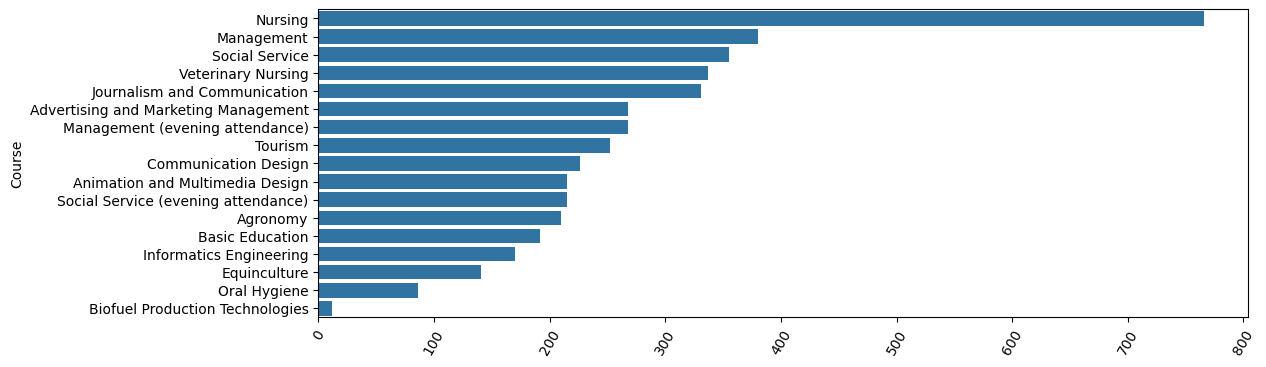

In [23]:
plot_bar('Course', courses, y=True)

> **Hay más estudiantes de enfermería.**

In [24]:
mar_status = new_dic('Marital Status')

,single,married,divorced,facto union,legally separated,widower
0,88.58%,8.57%,2.06%,0.57%,0.14%,0.09%


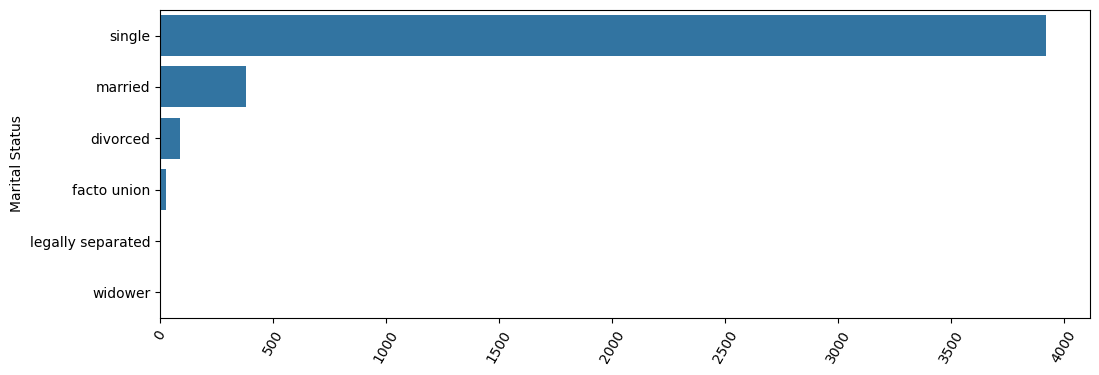

In [25]:
plot_bar('Marital Status', mar_status, y=True)

> **La mayoría de los alumnos son solteros.**

In [26]:
gender = new_dic('Gender')

,female,male
0,64.83%,35.17%


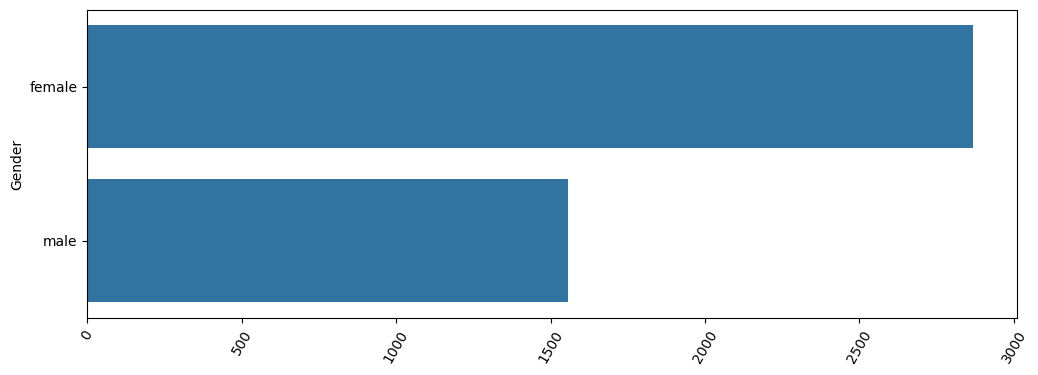

In [27]:
plot_bar('Gender', gender, y=True)

> **Hay más mujeres que hombres.**

In [28]:
nacionality = new_dic('Nacionality')

,Portuguese;,Brazilian;,Santomean;,Cape Verdean;,Spanish;,Guinean;,Moldova (Republic of);,Italian;,Ukrainian;,Angolan;,...,Romanian;,Mozambican;,German;,Russian;,Turkish;,Dutch;,Colombian,Cuban;,English;,Lithuanian;
0,97.51%,0.86%,0.32%,0.29%,0.29%,0.11%,0.07%,0.07%,0.07%,0.05%,...,0.05%,0.05%,0.05%,0.05%,0.02%,0.02%,0.02%,0.02%,0.02%,0.02%


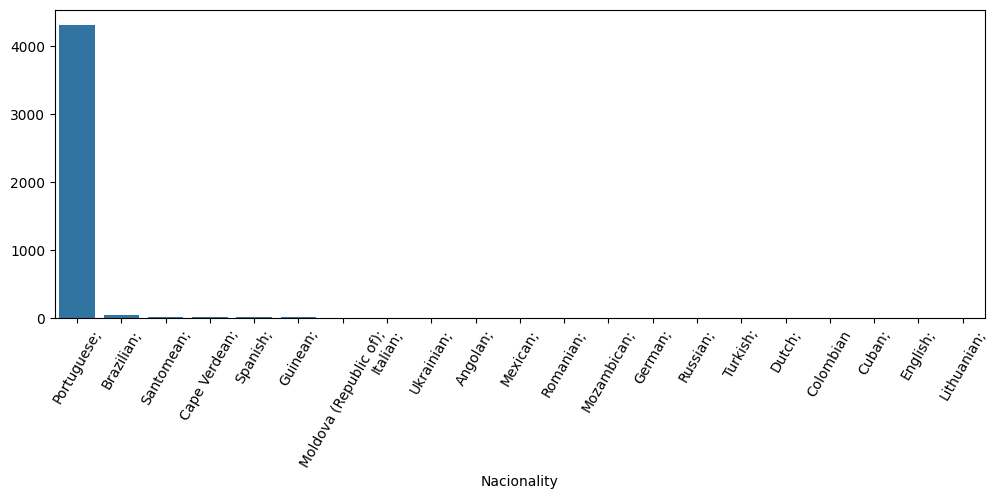

In [29]:
plot_bar('Nacionality', nacionality, x=True)

> **La mayoría de alumnos son portugueses.**

In [30]:
for row, x in description.loc[description.name.str.contains('mode')].iterrows():
    print(x['name'], end='\n\n')
    print(x['description'], end='\n\n')

Application mode

1 - 1st phase - general contingent 2 - Ordinance No. 612/93 5 - 1st phase - special contingent (Azores Island) 7 - Holders of other higher courses 10 - Ordinance No. 854-B/99 15 - International student (bachelor) 16 - 1st phase - special contingent (Madeira Island) 17 - 2nd phase - general contingent 18 - 3rd phase - general contingent 26 - Ordinance No. 533-A/99, item b2) (Different Plan) 27 - Ordinance No. 533-A/99, item b3 (Other Institution) 39 - Over 23 years old 42 - Transfer 43 - Change of course 44 - Technological specialization diploma holders 51 - Change of institution/course 53 - Short cycle diploma holders 57 - Change of institution/course (International)



In [31]:
app_mode = new_dic('Application mode')

,1st phase - general contingent,2nd phase - general contingent,Over 23 years old,Change of course,Technological specialization diploma holders,Holders of other higher courses,3rd phase - general contingent,Transfer,Change of institution/course,1st phase - special contingent (Madeira Island),Short cycle diploma holders,International student (bachelor),1st phase - special contingent (Azores Island),Ordinance No.,Ordinance No. 612/93,Change of institution/course (International)
0,38.61%,19.71%,17.74%,7.05%,4.81%,3.14%,2.80%,1.74%,1.33%,0.86%,0.79%,0.68%,0.36%,0.02%,0.07%,0.02%


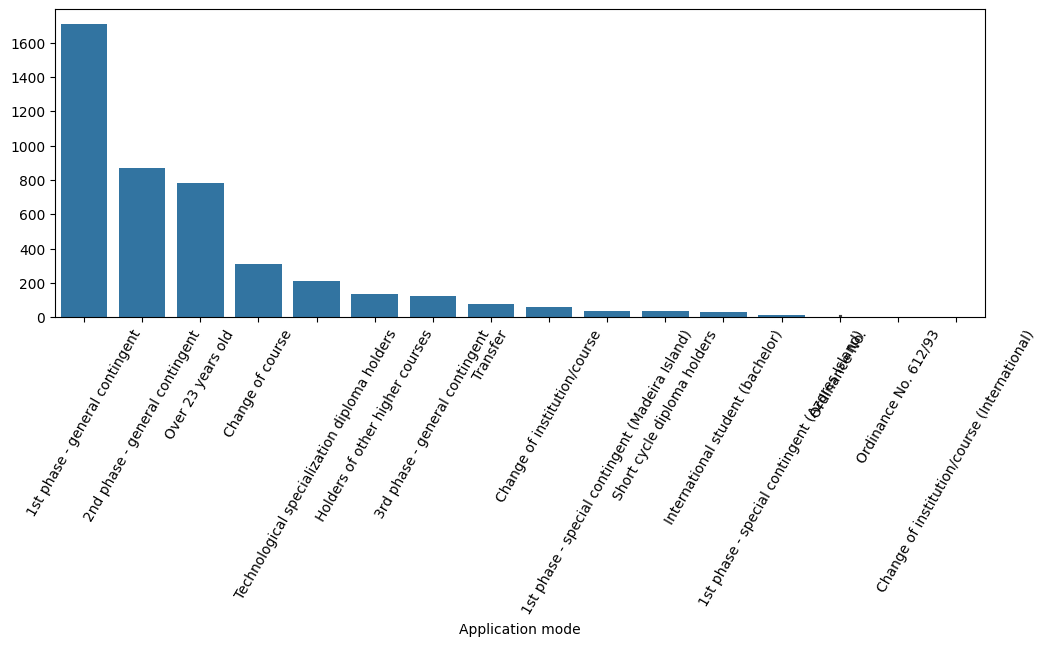

In [32]:
plot_bar('Application mode', app_mode, x=True)

In [33]:
for row, x in description.loc[description.name.str.contains('order')].iterrows():
    print(x['name'], end='\n\n')
    print(x['description'], end='\n\n')

Application order

Application order (between 0 - first choice; and 9 last choice)



,1,2,3,4,5,6,9,0
0,68.40%,12.36%,6.98%,5.63%,3.48%,3.10%,0.02%,0.02%


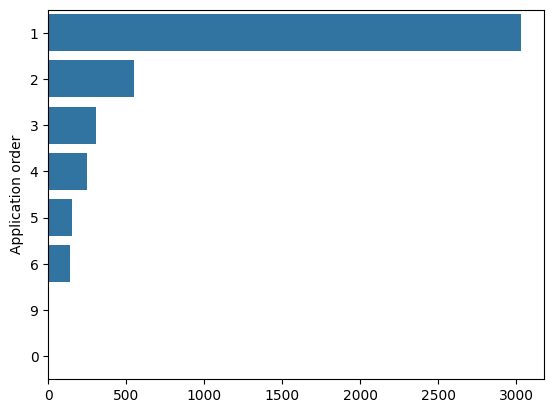

In [34]:
r = students['Application order'].value_counts()
r.index = r.index.astype(str)
# r.sort_index(inplace=True)

display(pd.DataFrame(pd.Series({x: '{:.2%}'.format(y / students.shape[0]) for x, y in r.items()})).T)
print()

sns.barplot(x=r.values, y=r.index)
plt.show()

In [35]:
for row, x in description.loc[description.name.str.contains('Mother')].iterrows():
    print(x['name'], end='\n\n')
    print(x['description'], end='\n\n')

Mother's qualification

1 - Secondary Education - 12th Year of Schooling or Eq. 2 - Higher Education - Bachelor's Degree 3 - Higher Education - Degree 4 - Higher Education - Master's 5 - Higher Education - Doctorate 6 - Frequency of Higher Education 9 - 12th Year of Schooling - Not Completed 10 - 11th Year of Schooling - Not Completed 11 - 7th Year (Old) 12 - Other - 11th Year of Schooling 14 - 10th Year of Schooling 18 - General commerce course 19 - Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv. 22 - Technical-professional course 26 - 7th year of schooling 27 - 2nd cycle of the general high school course 29 - 9th Year of Schooling - Not Completed 30 - 8th year of schooling 34 - Unknown 35 - Can't read or write 36 - Can read without having a 4th year of schooling 37 - Basic education 1st cycle (4th/5th year) or equiv. 38 - Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv. 39 - Technological specialization course 40 - Higher education - degree (1st cycle) 41 - Specialized

In [36]:
m_qual = new_dic("Mother's qualification")

In [125]:
f_qual = new_dic("Father's qualification")

In [132]:
qual_all = m_qual.copy()
qual_all.update(f_qual)

,Secondary Education - 12th Year of Schooling or Eq.,Basic education 1st cycle (4th/5th year) or equiv.,Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.,Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.,Higher Education - Degree,Unknown,Higher Education - Bachelor's Degree,Higher Education - Master's,Other - 11th Year of Schooling,Higher Education - Doctorate,...,7th Year (Old),Can read without having a 4th year of schooling,Can't read or write,8th year of schooling,10th Year of Schooling,General commerce course,Technical-professional course,2nd cycle of the general high school course,7th year of schooling,Higher Education - Doctorate (3rd cycle)
0,24.16%,22.81%,21.54%,12.70%,9.90%,2.94%,1.88%,1.11%,0.95%,0.47%,...,0.07%,0.07%,0.07%,0.07%,0.05%,0.02%,0.02%,0.02%,0.02%,0.02%


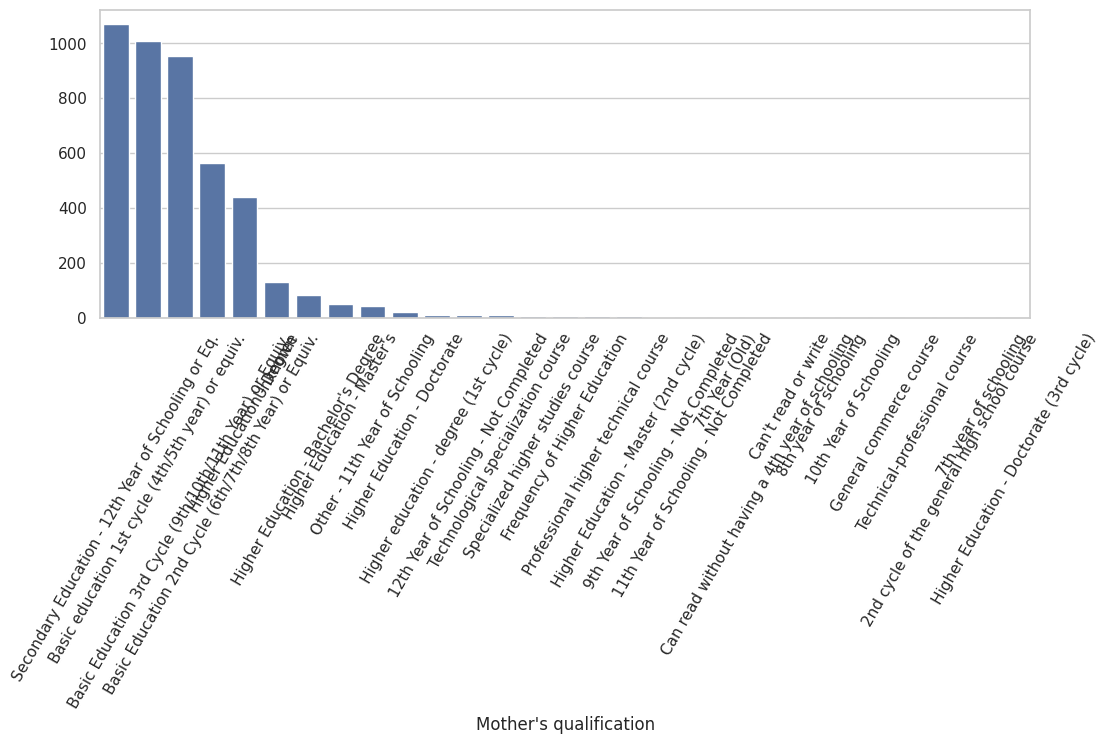

In [136]:
plot_bar("Mother's qualification", qual_all, x=True)

In [38]:
m_ocup = new_dic("Mother's occupation")

In [137]:
f_ocup = new_dic("Father's occupation")

In [138]:
ocup_all = m_ocup.copy()
ocup_all.update(f_ocup)

,Unskilled Workers,Administrative staff,"Personal Services, Security and Safety Workers and Sellers",Intermediate Level Technicians and Professions,Specialists in Intellectual and Scientific Activities,"Skilled Workers in Industry, Construction and Craftsmen",Student,"Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers","Farmers and Skilled Workers in Agriculture, Fisheries and Forestry",Other Situation,...,"Data, accounting, statistical, financial services and registry-related operators",personal service workers,"Technicians and professionals, of intermediate level of health",sellers,Health professionals,Personal care workers and the like,"Skilled workers in printing, precision instrument manufacturing, jewelers, artisans and the like",Specialists in information and communication technologies (ICT),Intermediate level science and engineering technicians and professions,"Skilled construction workers and the like, except electricians"
0,35.65%,18.47%,11.98%,7.93%,7.19%,6.15%,3.25%,2.31%,2.06%,1.58%,...,0.07%,0.07%,0.07%,0.05%,0.05%,0.05%,0.02%,0.02%,0.02%,0.02%


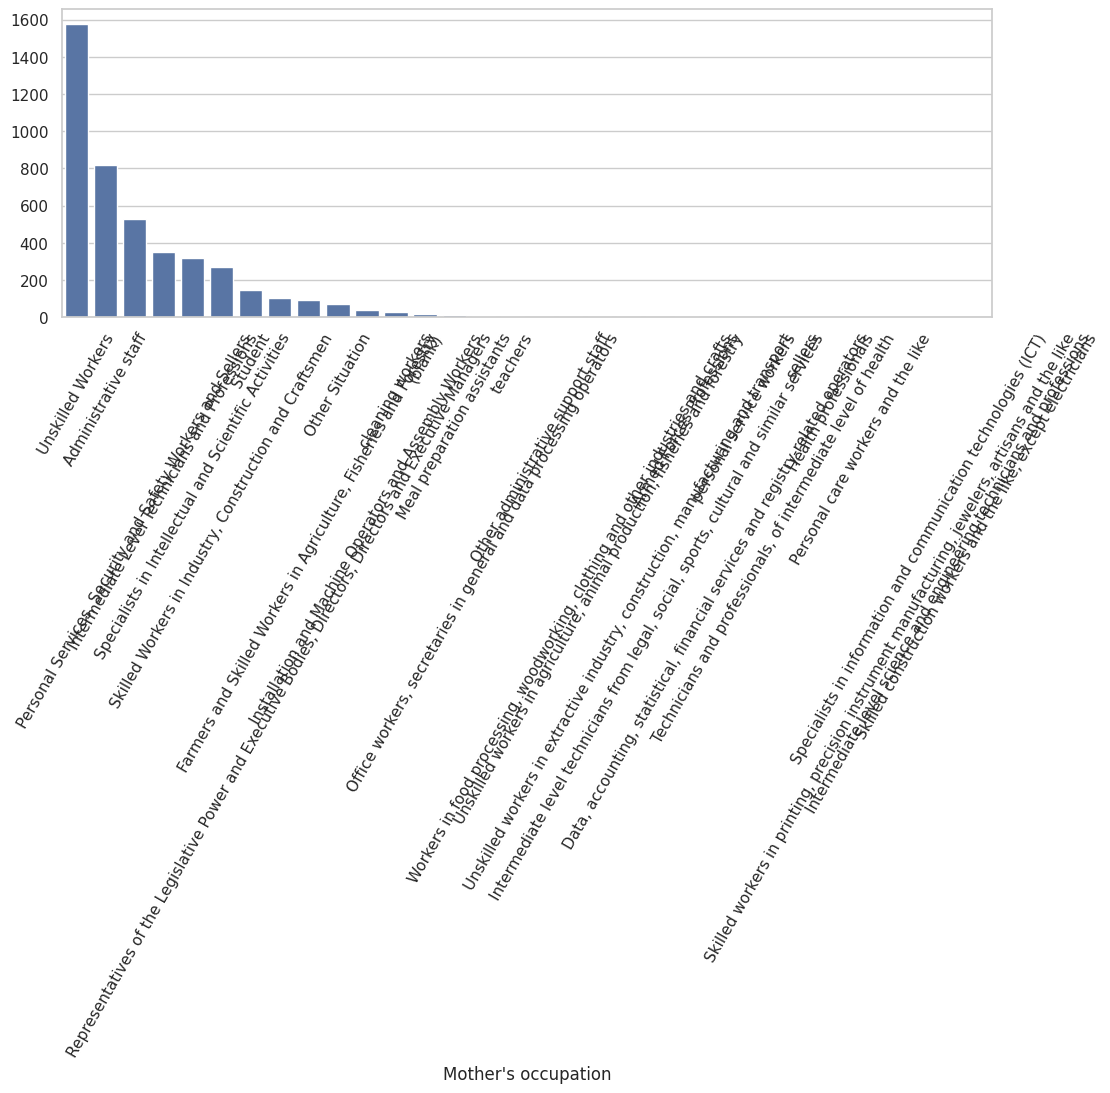

In [139]:
plot_bar("Mother's occupation", ocup_all, x=True)

In [40]:
locf('International')

'1 – yes 0 – no'

In [41]:
locf('Scholarship holder')

'1 – yes 0 – no'

In [42]:
locf('Tuition fees up to date')

'1 – yes 0 – no'

In [43]:
locf('Debtor')

'1 – yes 0 – no'

In [44]:
locf('Educational special needs')

'1 – yes 0 – no'

Variables categóricas desbalanceadas
* Daytime / evening attendance
* Educational special needs
* Debtor (could go)
* Tuition fees up to date (could go)
* International

In [45]:
cols = [
    'Debtor',
    'Daytime/evening attendance',
    'Educational special needs',
    'Tuition fees up to date',
    'International',
    'Application order'
]

mask = description['name'].isin(cols)

description.loc[mask, ['name', 'description']]

,name,description
2,Application order,Application order (between 0 - first choice; a...
4,Daytime/evening attendance,1 – daytime 0 - evening
14,Educational special needs,1 – yes 0 – no
15,Debtor,1 – yes 0 – no
16,Tuition fees up to date,1 – yes 0 – no
20,International,1 – yes 0 – no


## Descripción de Variables

In [46]:
description

,name,role,type,demographic,description,units,missing_values
0,Marital Status,Feature,Integer,Marital Status,1 – single 2 – married 3 – widower 4 – divorce...,None,no
1,Application mode,Feature,Integer,None,1 - 1st phase - general contingent 2 - Ordinan...,None,no
2,Application order,Feature,Integer,None,Application order (between 0 - first choice; a...,None,no
3,Course,Feature,Integer,None,33 - Biofuel Production Technologies 171 - Ani...,None,no
4,Daytime/evening attendance,Feature,Integer,None,1 – daytime 0 - evening,None,no
5,Previous qualification,Feature,Integer,Education Level,1 - Secondary education 2 - Higher education -...,None,no
6,Previous qualification (grade),Feature,Continuous,None,Grade of previous qualification (between 0 and...,None,no
7,Nacionality,Feature,Integer,Nationality,1 - Portuguese; 2 - German; 6 - Spanish; 11 - ...,None,no
8,Mother's qualification,Feature,Integer,Education Level,1 - Secondary Education - 12th Year of Schooli...,None,no
9,Father's qualification,Feature,Integer,Education Level,1 - Secondary Education - 12th Year of Schooli...,None,no


## Limpieza

In [142]:
students_clean = students.copy()

In [143]:
students_clean.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [144]:
students_clean.columns = [s.lower().replace(' ', '_').replace('(', '').replace(')', '') for s in students_clean.columns]

In [145]:
mask = students_clean.columns.astype(str).str.startswith('curricular')

In [146]:
cols = students_clean.columns[mask].tolist()

In [147]:
students_clean.loc[:, ['target']+cols]

,target,curricular_units_1st_sem_credited,curricular_units_1st_sem_enrolled,curricular_units_1st_sem_evaluations,curricular_units_1st_sem_approved,curricular_units_1st_sem_grade,curricular_units_1st_sem_without_evaluations,curricular_units_2nd_sem_credited,curricular_units_2nd_sem_enrolled,curricular_units_2nd_sem_evaluations,curricular_units_2nd_sem_approved,curricular_units_2nd_sem_grade,curricular_units_2nd_sem_without_evaluations
0,Dropout,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0
1,Graduate,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0
2,Dropout,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0
3,Graduate,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0
4,Graduate,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,Graduate,0,6,7,5,13.600000,0,0,6,8,5,12.666667,0
4420,Dropout,0,6,6,6,12.000000,0,0,6,6,2,11.000000,0
4421,Dropout,0,7,8,7,14.912500,0,0,8,9,1,13.500000,0
4422,Graduate,0,5,5,5,13.800000,0,0,5,6,5,12.000000,0


In [148]:
var_cat = students_clean.select_dtypes('object').columns.tolist() + [x for x in students_clean.columns if students_clean[x].unique().__len__() < 10]

In [149]:
var_num = [x for x in students_clean.columns if x not in var_cat]

In [150]:
percentiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99]

In [151]:
students_clean.loc[:, var_num].describe(percentiles).T

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
application_mode,4424.0,18.669078,17.484682,1.00,1.00,1.000,1.00,1.00,17.000000,39.000000,43.000000,44.000000,51.000,57.000000
course,4424.0,8856.642631,2063.566416,33.00,171.00,171.000,9003.00,9085.00,9238.000000,9556.000000,9853.000000,9991.000000,9991.000,9991.000000
previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000,1.00,1.00,1.000000,1.000000,19.000000,39.000000,40.000,43.000000
previous_qualification_grade,4424.0,132.613314,13.188332,95.00,100.00,110.000,117.00,125.00,133.100000,140.000000,150.000000,157.000000,170.000,190.000000
nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000,1.00,1.00,1.000000,1.000000,1.000000,1.000000,41.000,109.000000
mother's_qualification,4424.0,19.561935,15.603186,1.00,1.00,1.000,1.00,2.00,19.000000,37.000000,38.000000,38.000000,38.000,44.000000
father's_qualification,4424.0,22.275316,15.343108,1.00,1.00,1.000,1.00,3.00,19.000000,37.000000,38.000000,38.000000,38.000,44.000000
mother's_occupation,4424.0,10.960895,26.418253,0.00,0.00,1.000,2.00,4.00,5.000000,9.000000,9.000000,9.000000,191.000,194.000000
father's_occupation,4424.0,11.032324,25.263040,0.00,0.00,1.000,2.00,4.00,7.000000,9.000000,9.700000,10.000000,171.000,195.000000
admission_grade,4424.0,126.978119,14.482001,95.00,99.00,103.415,110.00,117.90,126.100000,134.800000,146.670000,153.500000,166.831,190.000000


Renombramiento de columnas con el formato deseado.

In [152]:
students_clean.columns

Index(['marital_status', 'application_mode', 'application_order', 'course',
       'daytime/evening_attendance', 'previous_qualification',
       'previous_qualification_grade', 'nacionality', 'mother's_qualification',
       'father's_qualification', 'mother's_occupation', 'father's_occupation',
       'admission_grade', 'displaced', 'educational_special_needs', 'debtor',
       'tuition_fees_up_to_date', 'gender', 'scholarship_holder',
       'age_at_enrollment', 'international',
       'curricular_units_1st_sem_credited',
       'curricular_units_1st_sem_enrolled',
       'curricular_units_1st_sem_evaluations',
       'curricular_units_1st_sem_approved', 'curricular_units_1st_sem_grade',
       'curricular_units_1st_sem_without_evaluations',
       'curricular_units_2nd_sem_credited',
       'curricular_units_2nd_sem_enrolled',
       'curricular_units_2nd_sem_evaluations',
       'curricular_units_2nd_sem_approved', 'curricular_units_2nd_sem_grade',
       'curricular_units_2nd_sem

### Agrupadores

In [153]:
def group_qualification(original_dict):
    groups = {}

    for code, text in original_dict.items():
        t = text.lower()

        # basic
        if ("basic education" in t or 
            "cycle" in t or
            "7th year" in t or
            "8th year" in t or
            "9th year" in t or
            "can read" in t or
            "not completed" in t or
            "older" in t or
            "commerce course" in t or
            "technical-professional" in t):
            groups[code] = "basic"

        # secondary
        elif ("secondary" in t or
              "12th year" in t or
              "11th year" in t or
              "10th year" in t):
            groups[code] = "secondary"

        # higher
        elif ("higher education" in t or
              "bachelor" in t or
              "master" in t or
              "degree" in t or
              "doctorate" in t):
            groups[code] = "higher"

        # other
        else:
            groups[code] = "other"

    return groups

In [154]:
students_clean['mothers_qualification_recat'] = students_clean["mother's_qualification"].astype(str).map(group_qualification(qual_all))

In [156]:
students_clean['fathers_qualification_recat'] = students_clean["father's_qualification"].astype(str).map(group_qualification(qual_all))

In [157]:
students_clean['mothers_qualification_recat'].isna().sum()

0

In [158]:
students_clean['fathers_qualification_recat'].isna().sum()

0

In [61]:
def group_occupation(original_dict):
    groups = {}

    for code, text in original_dict.items():
        t = text.lower()

        # professional
        if ("representatives" in t or 
            "executive" in t or
            "directors" in t or
            "specialists" in t or
            "professionals" in t or
            "health professionals" in t or
            "teachers" in t or
            "scientific" in t or
            "engineer" in t or
            "ict" in t):
            groups[code] = "professional"

        # skilled
        elif ("skilled workers" in t or 
              "crafts" in t or
              "manufacturing" in t or
              "installation" in t or
              "machine operators" in t):
            groups[code] = "skilled"

        # service
        elif ("services" in t or
              "security" in t or
              "sellers" in t or
              "personal services" in t or
              "office workers" in t or
              "administrative" in t or
              "data processing" in t):
            groups[code] = "service"

        # unskilled
        elif ("unskilled" in t or
              "cleaning" in t or
              "labor" in t or
              "extractive" in t):
            groups[code] = "unskilled"

        # other
        else:
            groups[code] = "other"

    return groups

In [159]:
students_clean['mothers_occupation_recat'] = students_clean["mother's_occupation"].astype(str).map(group_occupation(ocup_all))

In [160]:
students_clean['fathers_occupation_recat'] = students_clean["father's_occupation"].astype(str).map(group_occupation(ocup_all))

In [161]:
students_clean['mothers_occupation_recat'].isna().sum()

0

In [162]:
students_clean['fathers_occupation_recat'].isna().sum()

0

In [163]:
def group_application_order(x):
    if x in [0, 1]:   # Alta preferencia
        return 'high_pref'
    else:
        return 'low_pref'

In [164]:
students_clean['pref'] = students_clean["application_order"].apply(group_application_order)

In [165]:
app_mode_groups = {
    # General contingent
    '1': 'general',
    '2': 'general',
    '3': 'general_special',
    '5': 'general_special',
    '17': 'general',
    '18': 'general',

    # Over 23
    '39': 'over23',

    # Change of course / institution
    '42': 'change',
    '43': 'change',
    '53': 'change',

    # Specialized diploma holders
    '44': 'specialized',
    '51': 'specialized',
    '57': 'specialized',

    # Other higher courses / international
    '7': 'higher_holders',
    '10': 'higher_holders',
    '15': 'higher_holders',
    '27': 'higher_holders',
    '26': 'higher_holders',
    '16': 'higher_holders',

    # Default fallback
    # Anything not listed goes to "other"
}


students_clean['application_mode_recat'] = (
    students_clean['application_mode']
    .astype(str)
    .map(app_mode_groups)
    .fillna('other')
)

### Ocupación de padres

,skilled,service,other,professional,unskilled
0,45.00%,30.97%,13.63%,9.81%,0.59%


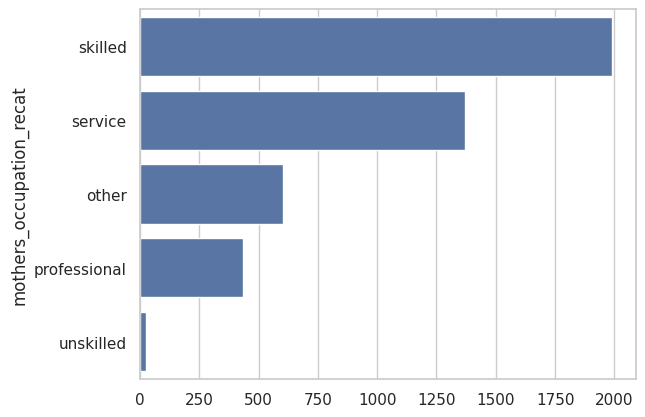

In [166]:
r = students_clean['mothers_occupation_recat'].value_counts()
r.index = r.index.astype(str)
# r.sort_index(inplace=True)

display(pd.DataFrame(pd.Series({x: '{:.2%}'.format(y / students_clean.shape[0]) for x, y in r.items()})).T)
print()

sns.barplot(x=r.values, y=r.index)
plt.show()

,skilled,service,other,professional
0,51.24%,20.73%,20.28%,7.75%


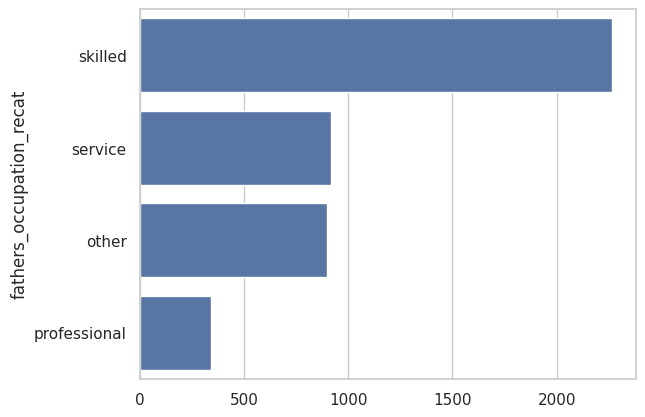

In [167]:
r = students_clean['fathers_occupation_recat'].value_counts()
r.index = r.index.astype(str)
# r.sort_index(inplace=True)

display(pd.DataFrame(pd.Series({x: '{:.2%}'.format(y / students_clean.shape[0]) for x, y in r.items()})).T)
print()

sns.barplot(x=r.values, y=r.index)
plt.show()

### Educación de padres

,basic,secondary,higher,other
0,57.98%,25.16%,13.45%,3.41%


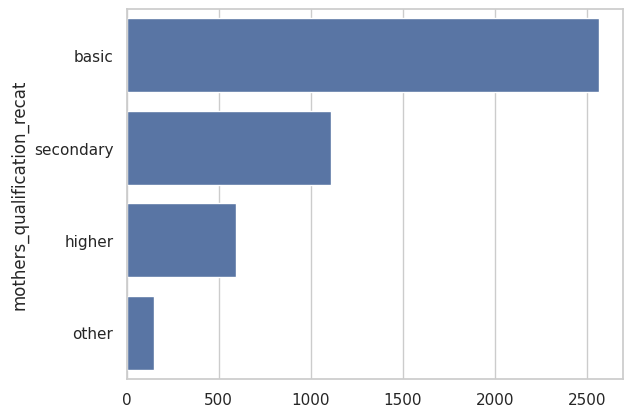

In [168]:
r = students_clean['mothers_qualification_recat'].value_counts()
r.index = r.index.astype(str)
# r.sort_index(inplace=True)

display(pd.DataFrame(pd.Series({x: '{:.2%}'.format(y / students_clean.shape[0]) for x, y in r.items()})).T)
print()

sns.barplot(x=r.values, y=r.index)
plt.show()

,basic,secondary,higher,other
0,66.16%,21.38%,9.25%,3.21%


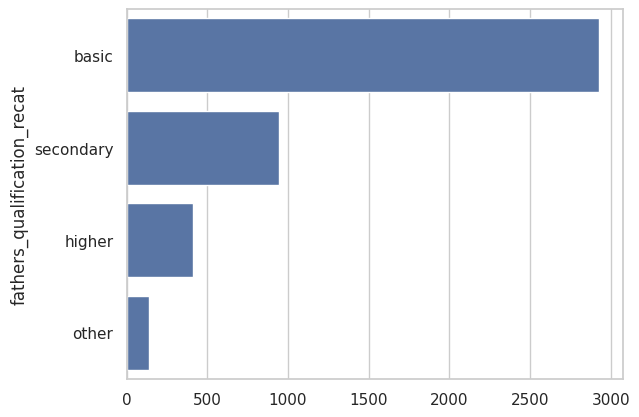

In [169]:
r = students_clean['fathers_qualification_recat'].value_counts()
r.index = r.index.astype(str)
# r.sort_index(inplace=True)

display(pd.DataFrame(pd.Series({x: '{:.2%}'.format(y / students_clean.shape[0]) for x, y in r.items()})).T)
print()

sns.barplot(x=r.values, y=r.index)
plt.show()

### Target por tipo de opción preferida

proportion
pref      target              
high_pref Graduate   46.547737
          Dropout    34.786918
          Enrolled   18.665345
low_pref  Graduate   57.265569
          Dropout    26.342162
          Enrolled   16.392269

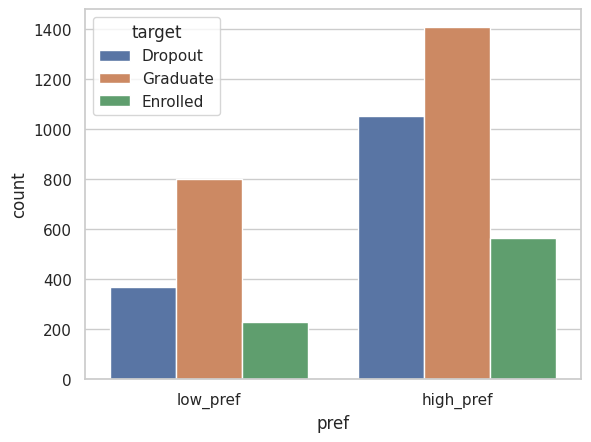

In [170]:
display(pd.DataFrame(students_clean.groupby("pref")["target"].value_counts(normalize=True).mul(100)))

sns.countplot(x="pref", hue="target", data=students_clean)
plt.show()

> **El abandono no está explicado únicamente por si obtuvieron su opción preferida.**

---

Aunque la mayoría de los estudiantes recibió una opción de alta preferencia (0–1), se observa un volumen alto de abandono incluso en este grupo. 

Sin embargo, esto es esperado: el grupo high_pref concentra más del 80% de los estudiantes, por lo que naturalmente acumula más casos de abandono. 

Para obtener una visión más clara, es necesario comparar **tasas de abandono**, lo cual generalmente muestra que el abandono es proporcionalmente mayor en aquellos estudiantes que no obtuvieron una opción preferente (low_pref), a pesar del menor volumen absoluto.

---

A pesar de que podría esperarse que los estudiantes asignados a su primera opción mostraran menor riesgo de abandono, los datos revelan lo contrario: la tasa de dropout es mayor en el grupo high_pref (34.8%) que en el grupo low_pref (26.3%).

Esto sugiere que obtener la opción de preferencia no es un predictor fuerte del compromiso académico o del éxito posterior.

En consecuencia, el “Application Order” no debe interpretarse como un determinante directo del riesgo de abandono, y su relevancia predictiva es limitada dentro del modelo.

In [171]:
description

,name,role,type,demographic,description,units,missing_values
0,Marital Status,Feature,Integer,Marital Status,1 – single 2 – married 3 – widower 4 – divorce...,None,no
1,Application mode,Feature,Integer,None,1 - 1st phase - general contingent 2 - Ordinan...,None,no
2,Application order,Feature,Integer,None,Application order (between 0 - first choice; a...,None,no
3,Course,Feature,Integer,None,33 - Biofuel Production Technologies 171 - Ani...,None,no
4,Daytime/evening attendance,Feature,Integer,None,1 – daytime 0 - evening,None,no
5,Previous qualification,Feature,Integer,Education Level,1 - Secondary education 2 - Higher education -...,None,no
6,Previous qualification (grade),Feature,Continuous,None,Grade of previous qualification (between 0 and...,None,no
7,Nacionality,Feature,Integer,Nationality,1 - Portuguese; 2 - German; 6 - Spanish; 11 - ...,None,no
8,Mother's qualification,Feature,Integer,Education Level,1 - Secondary Education - 12th Year of Schooli...,None,no
9,Father's qualification,Feature,Integer,Education Level,1 - Secondary Education - 12th Year of Schooli...,None,no


In [172]:
students_clean.columns

Index(['marital_status', 'application_mode', 'application_order', 'course',
       'daytime/evening_attendance', 'previous_qualification',
       'previous_qualification_grade', 'nacionality', 'mother's_qualification',
       'father's_qualification', 'mother's_occupation', 'father's_occupation',
       'admission_grade', 'displaced', 'educational_special_needs', 'debtor',
       'tuition_fees_up_to_date', 'gender', 'scholarship_holder',
       'age_at_enrollment', 'international',
       'curricular_units_1st_sem_credited',
       'curricular_units_1st_sem_enrolled',
       'curricular_units_1st_sem_evaluations',
       'curricular_units_1st_sem_approved', 'curricular_units_1st_sem_grade',
       'curricular_units_1st_sem_without_evaluations',
       'curricular_units_2nd_sem_credited',
       'curricular_units_2nd_sem_enrolled',
       'curricular_units_2nd_sem_evaluations',
       'curricular_units_2nd_sem_approved', 'curricular_units_2nd_sem_grade',
       'curricular_units_2nd_sem

In [173]:
sns.set(style="whitegrid")

df = students_clean  # por comodidad


# Continuas "claras"
cont_vars = [
    "age_at_enrollment",
    "gdp",
    "unemployment_rate",
    "admission_grade",
    "curricular_units_1st_sem_grade",
    "curricular_units_2nd_sem_grade",
]

# Variables numéricas tipo conteo (curricular units)
curricular_vars = [
    "curricular_units_1st_sem_credited",
    "curricular_units_1st_sem_enrolled",
    "curricular_units_1st_sem_evaluations",
    "curricular_units_1st_sem_approved",
    "curricular_units_1st_sem_without_evaluations",
    "curricular_units_2nd_sem_credited",
    "curricular_units_2nd_sem_enrolled",
    "curricular_units_2nd_sem_evaluations",
    "curricular_units_2nd_sem_approved",
    "curricular_units_2nd_sem_without_evaluations",
]

# Agrupadores de padres/madres
family_cat_vars = [
    "mothers_qualification_recat",
    "fathers_qualification_recat",
    "mothers_occupation_recat",
    "fathers_occupation_recat",
]

# Por si alguna columna no existe, filtramos
cont_vars        = [c for c in cont_vars        if c in df.columns]
curricular_vars  = [c for c in curricular_vars  if c in df.columns]
family_cat_vars  = [c for c in family_cat_vars  if c in df.columns]

def boxplots_by_target_gender(df, cols):
    """
    Para cada variable en cols, hace un boxplot:
    - Panel por género (col='gender')
    - Colores / leyenda por target (hue='target')
    """
    for col in cols:
        g = sns.catplot(
            data=df,
            kind="box",
            x="target",
            y=col,
            hue="target",
            col="gender",
            sharey=False,
            height=4,
            aspect=1.1
        )
        g.fig.suptitle(f"{col} por target y género", y=1.05)
        g.set_xlabels("Target")
        g.set_ylabels(col)
        plt.show()

def countplots_family_cats(df, cols):
    """
    Para cada variable categórica de padres/madres,
    hace un countplot:
    - eje x = categoría
    - hue = target (leyenda)
    - col = gender (separación por género)
    """
    for col in cols:
        g = sns.catplot(
            data=df,
            kind="count",
            x=col,
            hue="target",
            col="gender",
            height=4,
            aspect=1.4
        )
        g.fig.suptitle(f"{col} vs target, separado por género", y=1.05)
        for ax in g.axes.flat:
            #ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha="right")
            ax.tick_params(axis="x", labelrotation=60)
        g.set_xlabels(col)
        g.set_ylabels("count")
        plt.show()

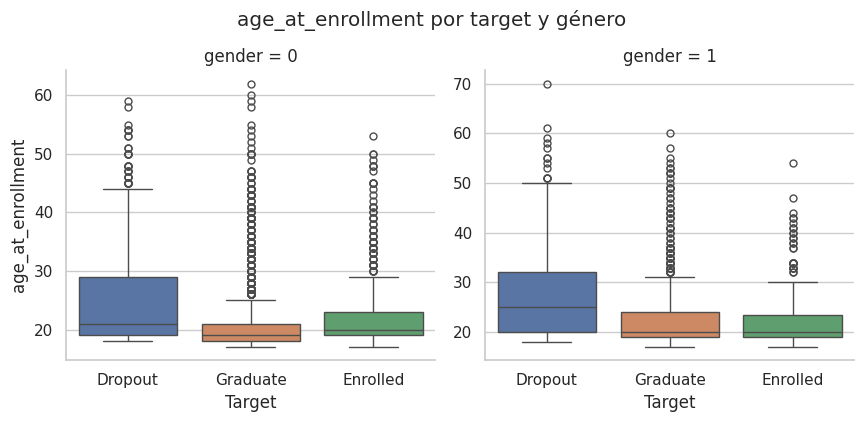

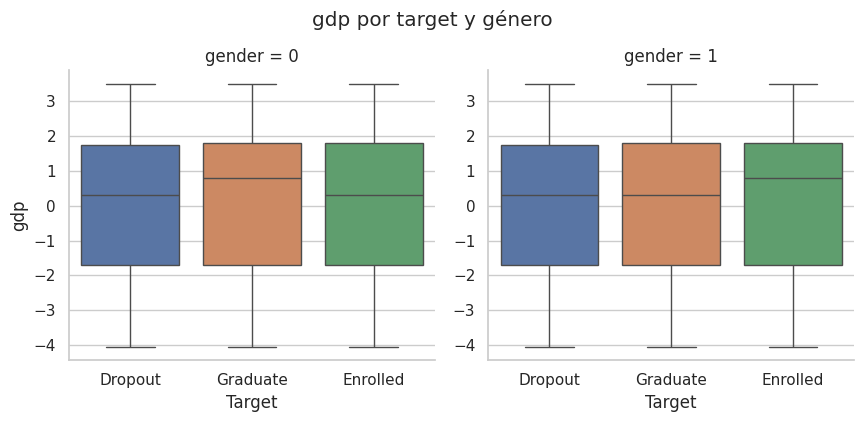

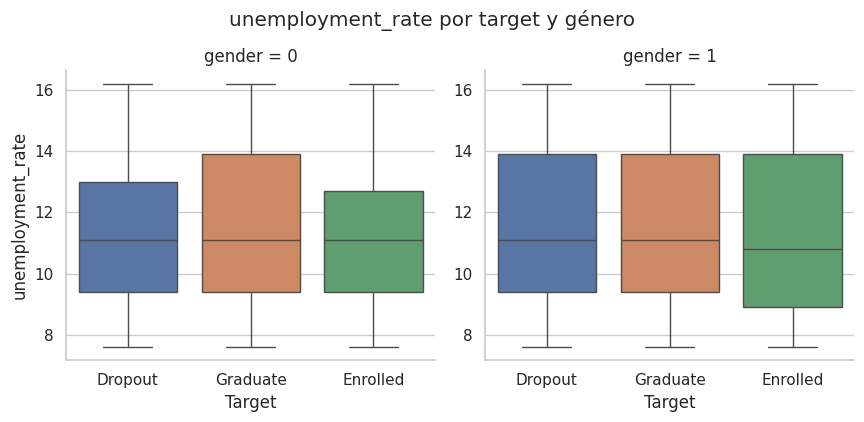

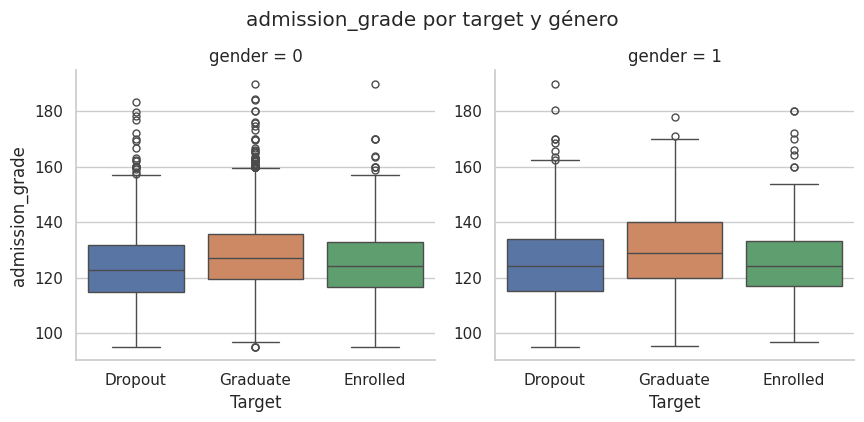

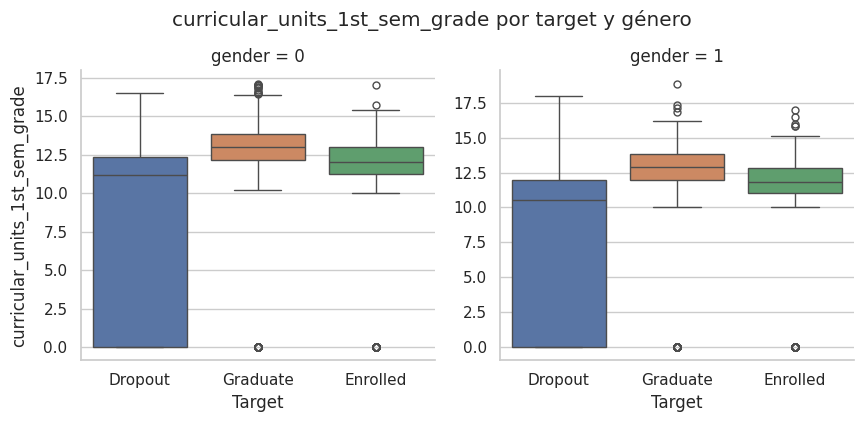

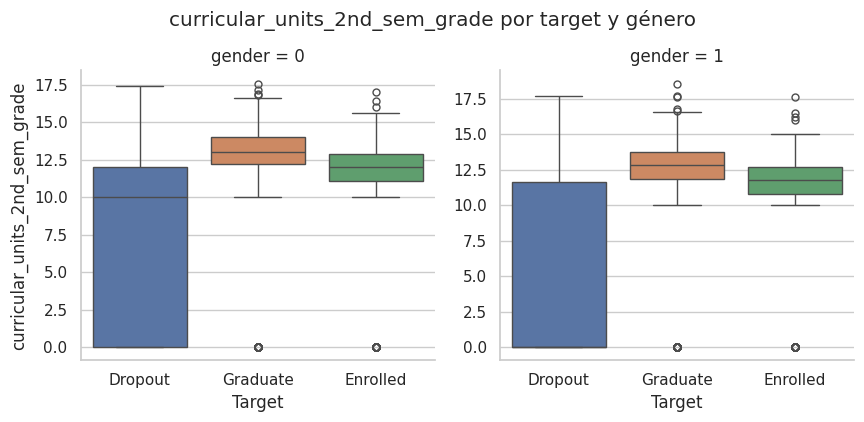

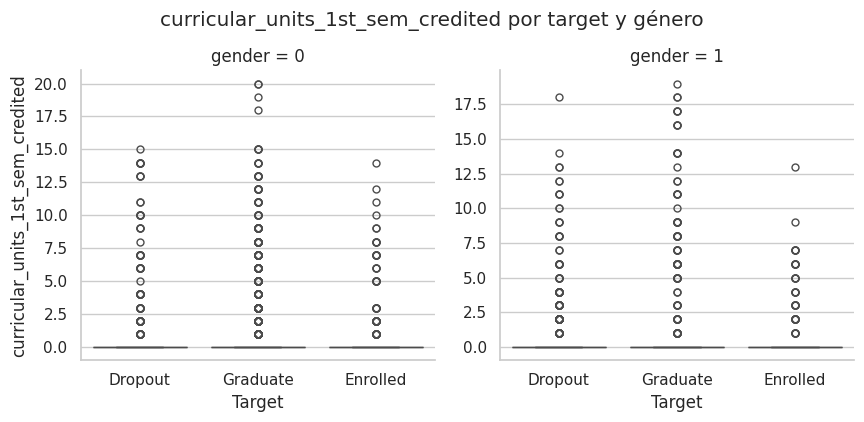

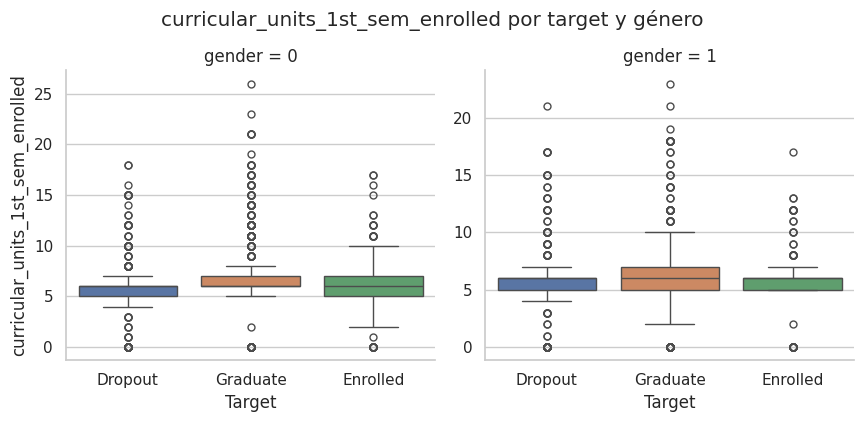

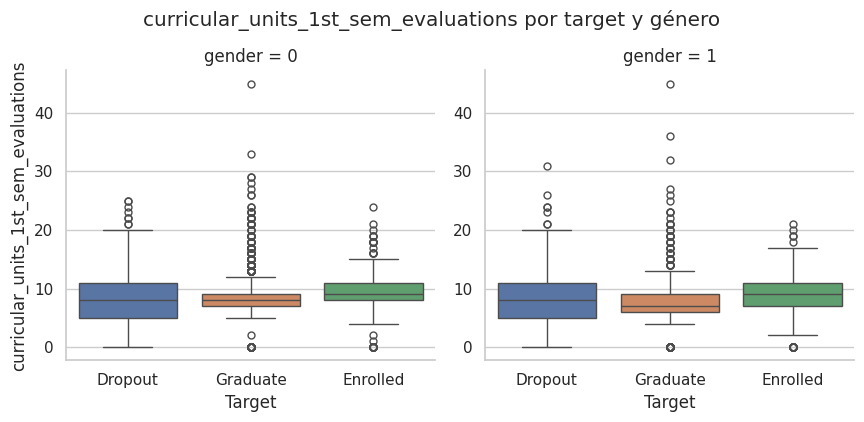

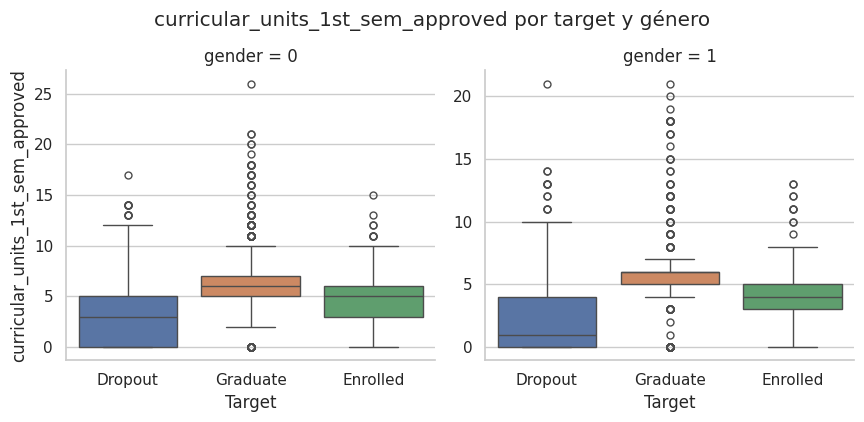

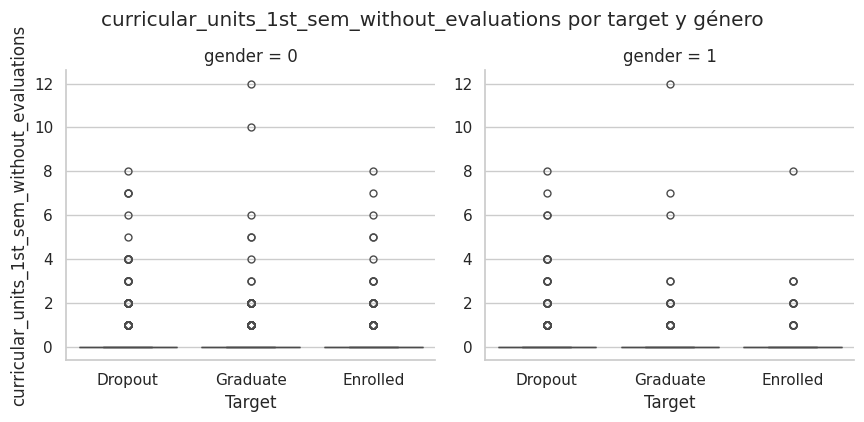

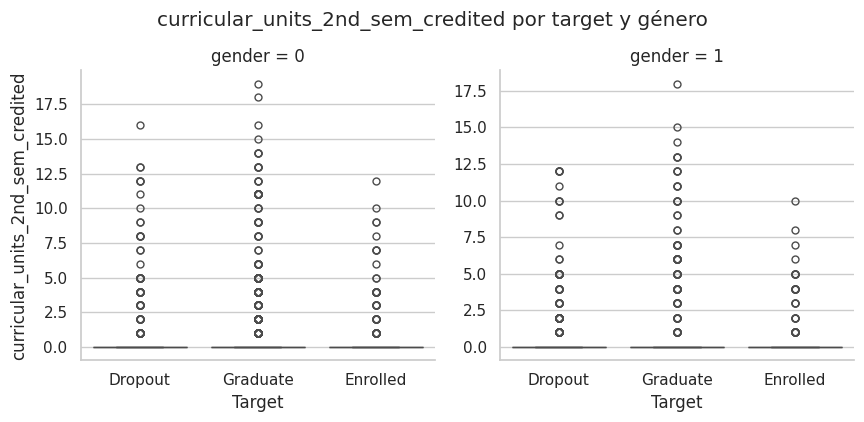

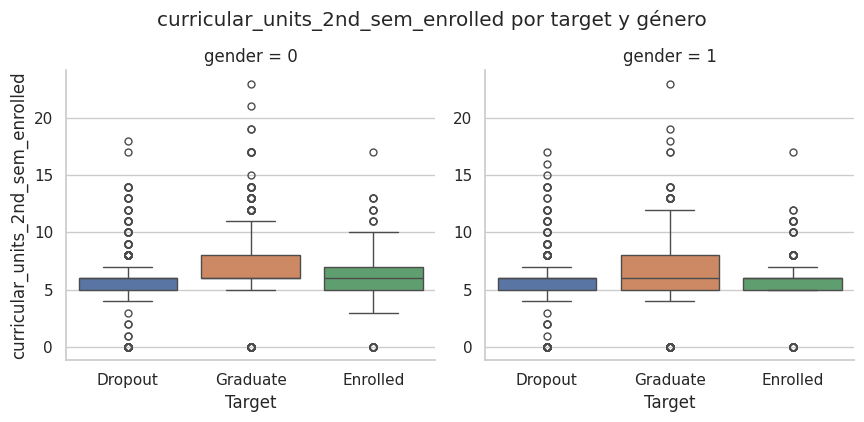

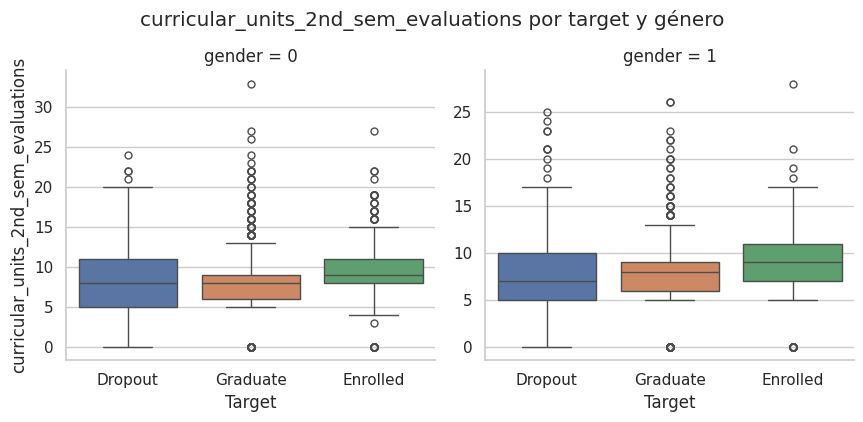

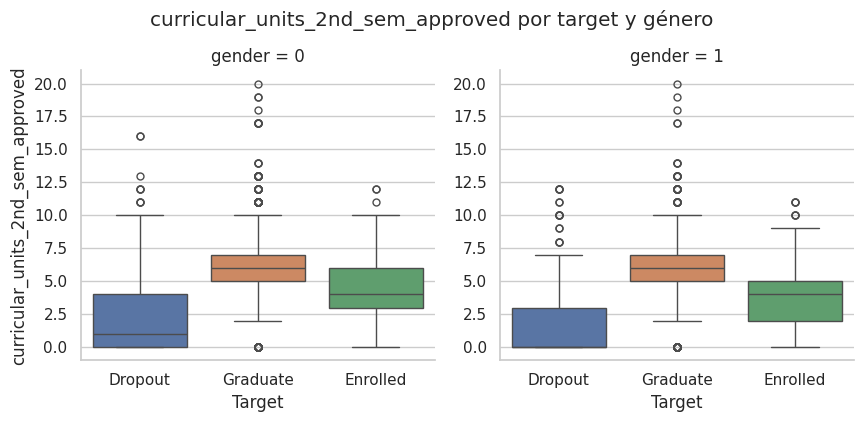

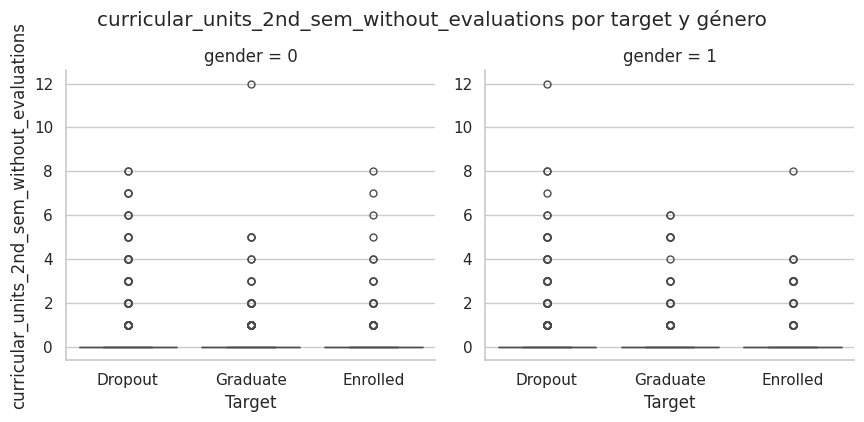

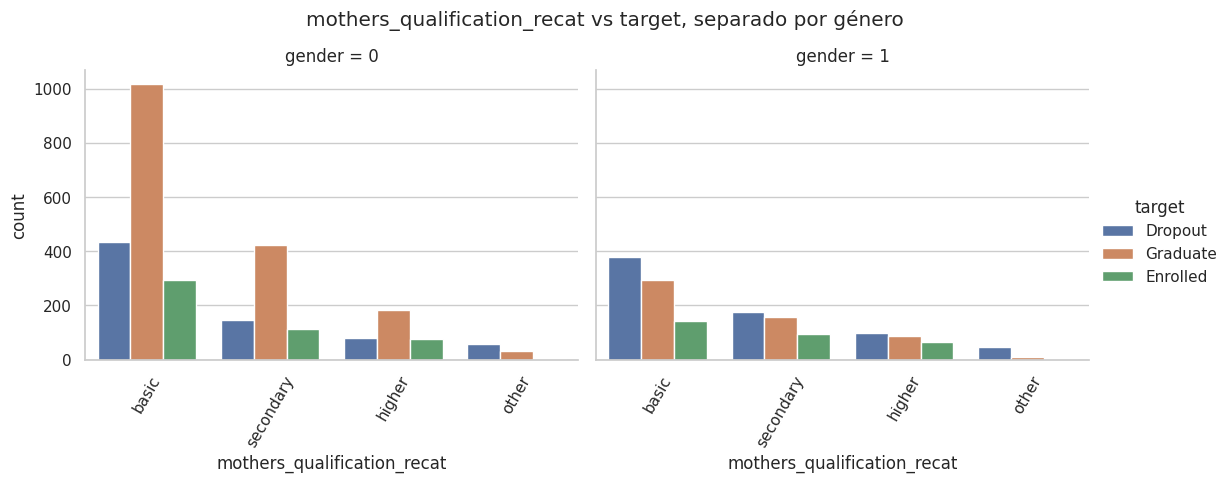

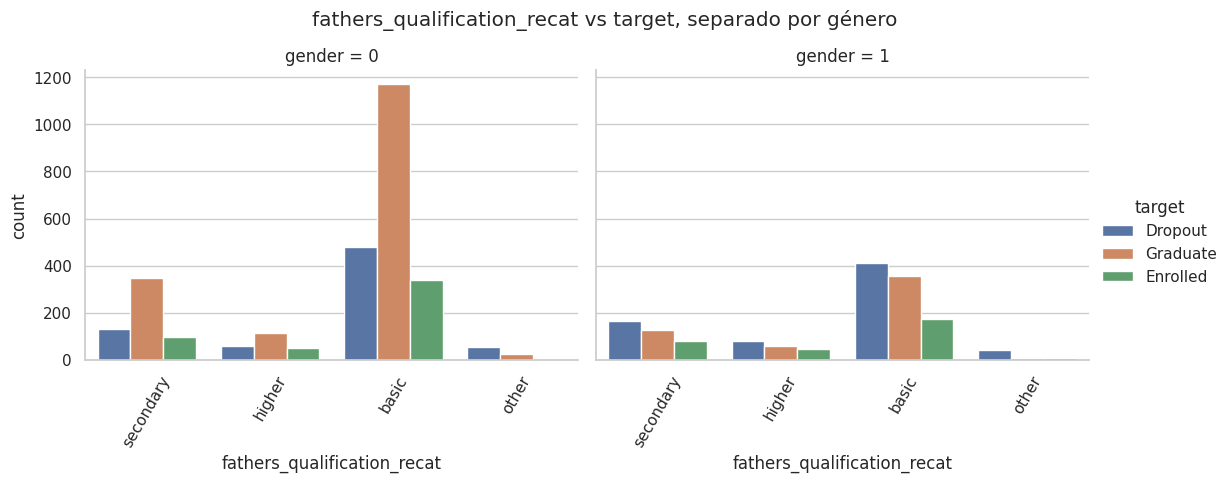

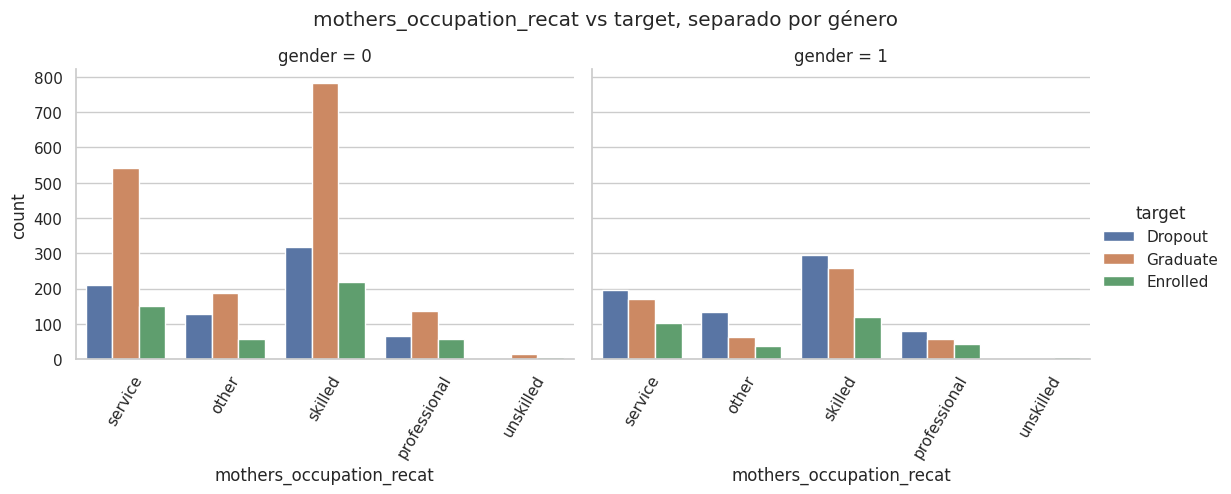

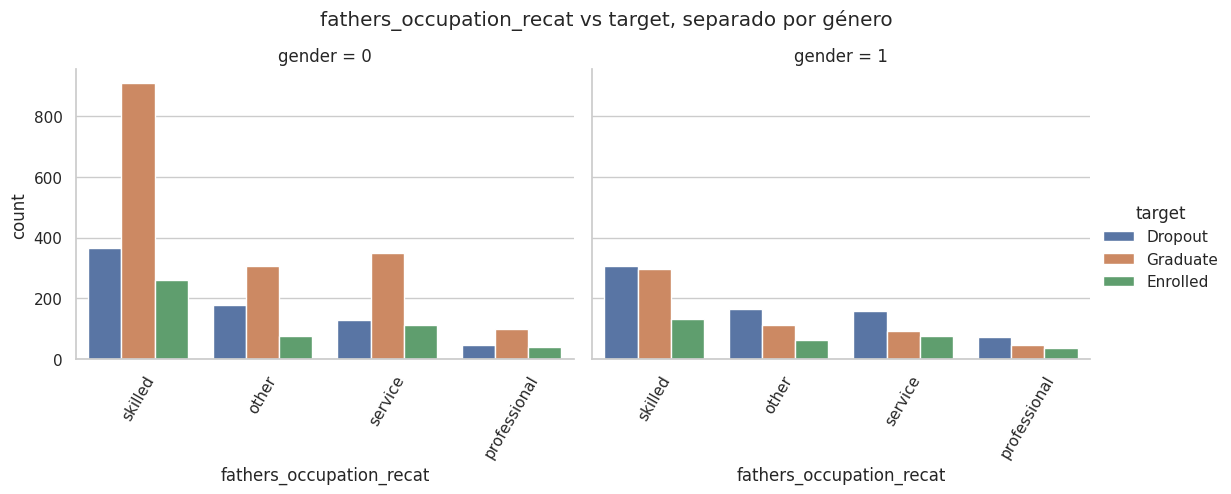

In [174]:
# Boxplots de continuas "limpias"
boxplots_by_target_gender(df, cont_vars)

# Boxplots de las variables de curricular units
boxplots_by_target_gender(df, curricular_vars)

# Barplots de educación y ocupación de padres/madres
countplots_family_cats(df, family_cat_vars)

* El rango intercuantil de edad en estudiantes que no se gradúan está entre 19 y 31 años con valores atípicos hacia más de 45
* De los que se gradúan está entre 18 y 21 años con valores atípicos hacia más de 37
* Mientras que los que están enrolados va el rango de los 19 a los 25 años con valores atípicos hacia más de 38

In [175]:
(
    students_clean
        .groupby('target')['age_at_enrollment']
        .describe(percentiles=percentiles)
)

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
target,,,,,,,,,,,,,,
Dropout,1421.0,26.068966,8.704024,18.0,18.0,18.0,18.0,19.0,23.0,30.0,39.0,45.0,53.00,70.0
Enrolled,794.0,22.369018,6.302672,17.0,18.0,18.0,18.0,19.0,20.0,23.0,31.0,37.0,47.07,54.0
Graduate,2209.0,21.783612,6.693218,17.0,18.0,18.0,18.0,18.0,19.0,21.0,31.0,38.0,50.00,62.0


In [176]:
students_clean.columns

Index(['marital_status', 'application_mode', 'application_order', 'course',
       'daytime/evening_attendance', 'previous_qualification',
       'previous_qualification_grade', 'nacionality', 'mother's_qualification',
       'father's_qualification', 'mother's_occupation', 'father's_occupation',
       'admission_grade', 'displaced', 'educational_special_needs', 'debtor',
       'tuition_fees_up_to_date', 'gender', 'scholarship_holder',
       'age_at_enrollment', 'international',
       'curricular_units_1st_sem_credited',
       'curricular_units_1st_sem_enrolled',
       'curricular_units_1st_sem_evaluations',
       'curricular_units_1st_sem_approved', 'curricular_units_1st_sem_grade',
       'curricular_units_1st_sem_without_evaluations',
       'curricular_units_2nd_sem_credited',
       'curricular_units_2nd_sem_enrolled',
       'curricular_units_2nd_sem_evaluations',
       'curricular_units_2nd_sem_approved', 'curricular_units_2nd_sem_grade',
       'curricular_units_2nd_sem

In [177]:
mask = (students_clean['curricular_units_1st_sem_enrolled'] == 0) | (students_clean['curricular_units_2nd_sem_enrolled'] == 0)

a1 = (
    students_clean.loc[mask]
        .groupby('target')['curricular_units_1st_sem_credited']
        .count()
        .rename('n_students')
)

curr_cols = [c for c in students_clean.columns if c.startswith('curricular')]

a2 = (
    students_clean.loc[mask]
        .groupby('target')[curr_cols]
        .sum()
)

display(pd.concat([a1, a2], axis=1))

,n_students,curricular_units_1st_sem_credited,curricular_units_1st_sem_enrolled,curricular_units_1st_sem_evaluations,curricular_units_1st_sem_approved,curricular_units_1st_sem_grade,curricular_units_1st_sem_without_evaluations,curricular_units_2nd_sem_credited,curricular_units_2nd_sem_enrolled,curricular_units_2nd_sem_evaluations,curricular_units_2nd_sem_approved,curricular_units_2nd_sem_grade,curricular_units_2nd_sem_without_evaluations
target,,,,,,,,,,,,,
Dropout,77,0,0,0,0,0.0,0,0,0,0,0,0.0,0
Enrolled,28,0,0,0,0,0.0,0,0,0,0,0,0.0,0
Graduate,75,0,0,0,0,0.0,0,0,0,0,0,0.0,0


In [178]:
mask_zero_curr = (students_clean.filter(like='curricular_units').sum(axis=1) == 0)

print(students_clean.loc[mask_zero_curr, ['course', 'target']].value_counts())
print(students_clean.loc[mask_zero_curr, ['course', 'target']].value_counts(normalize=True).mul(100))

course  target  
171     Dropout     77
        Graduate    75
        Enrolled    28
Name: count, dtype: int64
course  target  
171     Dropout     42.777778
        Graduate    41.666667
        Enrolled    15.555556
Name: proportion, dtype: float64


Los 180 casos con información académica nula pertenecen exclusivamente al curso Animation and Multimedia Design (code 171), distribuidos en 42.9% dropout, 41.6% graduate y 15.5% enrolled.

Se identificaron 180 estudiantes del curso Animation and Multimedia Design para los cuales el número de unidades curriculares inscritas, evaluadas y aprobadas en ambos semestres es cero, mientras que sí se registra un estado final (dropout/enrolled/graduate).

Este patrón sugiere una inconsistencia en la fuente de datos para dicho curso (información académica ausente pero target presente), por lo cual estos registros fueron excluidos del conjunto de entrenamiento para evitar sesgos en el modelo.

In [179]:
students_clean.drop(index=students_clean.loc[mask].index, inplace=True)

In [180]:
drop_cols = [
    "mother's_qualification", 
    "father's_qualification", 
    "mother's_occupation", 
    "father's_occupation",
    'nacionality',
    'tuition_fees_up_to_date',
    'international',
    'daytime/evening_attendance',
    'educational_special_needs',
    'debtor'
]

In [181]:
for x in drop_cols:
    if 'father' not in x and 'mother' not in x:
        print(students_clean[x].value_counts(normalize=True))
        print()

nacionality
1      0.975495
41     0.007776
26     0.003299
22     0.003063
6      0.003063
24     0.001178
100    0.000707
11     0.000707
103    0.000707
21     0.000471
62     0.000471
25     0.000471
2      0.000471
105    0.000471
101    0.000236
32     0.000236
13     0.000236
109    0.000236
108    0.000236
14     0.000236
17     0.000236
Name: proportion, dtype: float64

tuition_fees_up_to_date
1    0.88148
0    0.11852
Name: proportion, dtype: float64

international
0    0.975495
1    0.024505
Name: proportion, dtype: float64

daytime/evening_attendance
1    0.886192
0    0.113808
Name: proportion, dtype: float64

educational_special_needs
0    0.989161
1    0.010839
Name: proportion, dtype: float64

debtor
0    0.886899
1    0.113101
Name: proportion, dtype: float64



In [182]:
bin_labels = {
    'debtor': {0: 'no_debt', 1: 'debtor'},
    'tuition_fees_up_to_date': {0: 'not_up_to_date', 1: 'up_to_date'},
    'daytime/evening_attendance': {0: 'evening', 1: 'daytime'}
}

# Colores fijos por clase (cámbialos si quieres otros)
target_order   = ['Dropout', 'Graduate', 'Enrolled']
target_palette = {
    'Dropout':  '#1f77b4',  # azul
    'Graduate': '#ff9896',  # rosa pastel
    'Enrolled': '#2ca02c',  # verde
}

def catplots_binary(df, cols, split_by_gender=True):
    for col in cols:
        temp_col = col + "_label"
        df[temp_col] = df[col].map(bin_labels[col])

        common_args = dict(
            data=df,
            kind="count",
            x=temp_col,
            hue="target",
            hue_order=target_order,
            palette=target_palette,
            height=4,
            aspect=1.3
        )

        if split_by_gender:
            g = sns.catplot(col="gender", **common_args)
        else:
            g = sns.catplot(**common_args)

        g.fig.suptitle(f"{col} vs target", y=1.05)
        for ax in g.axes.flat:
            ax.tick_params(axis="x", labelrotation=30)
        g.set_xlabels(col)
        g.set_ylabels("count")
        plt.show()

        df.drop(columns=[temp_col], inplace=True)

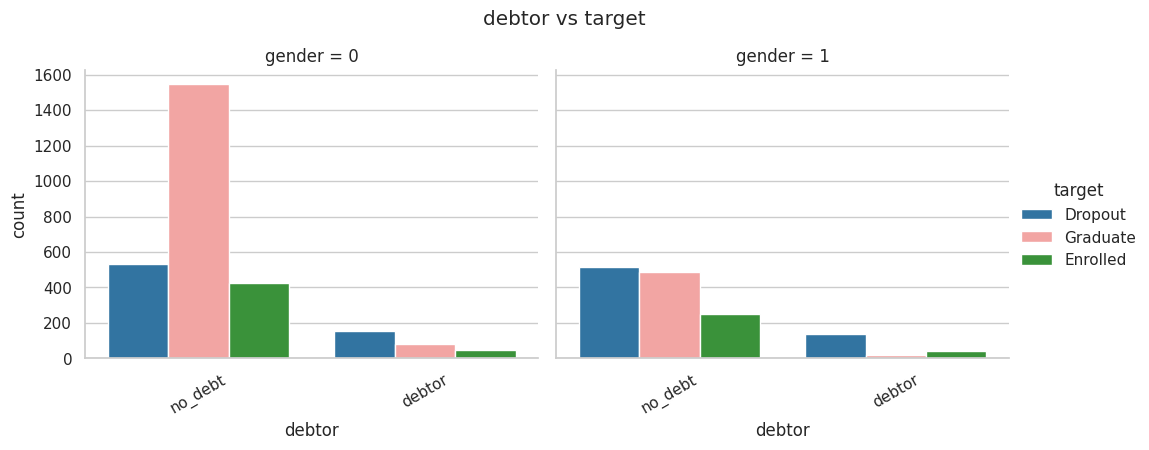

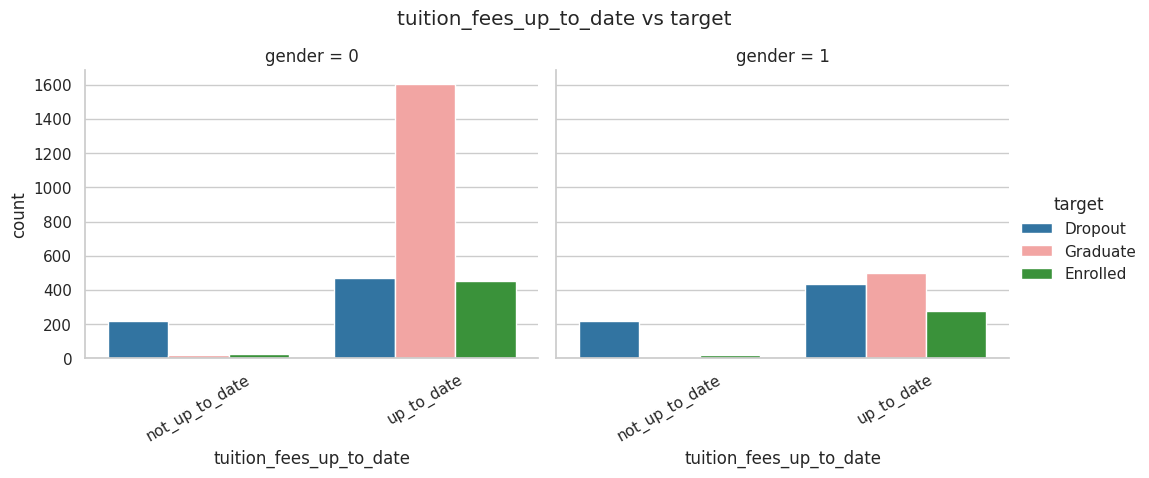

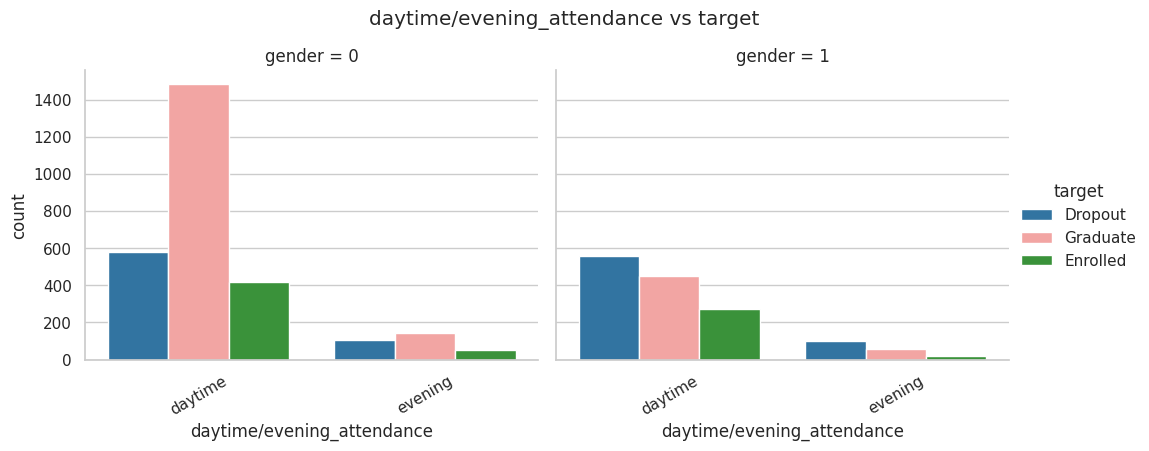

In [183]:
# Usar la función para tus 3 variables
cols_bin = ['debtor', 'tuition_fees_up_to_date', 'daytime/evening_attendance']
catplots_binary(students_clean, cols_bin, split_by_gender=True)

Variables categóricas desbalanceadas
* Daytime / evening attendance
* Educational special needs
* Debtor (could go)
* Tuition fees up to date (could go)
* International

Se decide dejar debtor, tuition fees up to date y daytime ya que tiene una alta relación con la variable objetivo para la clasificación de `graduate` en alumnas. La de international igual viene desbalanceada pero se va a recategorizar a una variables binaria donde 1 (portuguese) es local y el resto es considerado internacional, el resto de variables serán eliminadas porque han sido recategorizadas o porque tienen un alto desbalance.

In [184]:
drop_cols = [
    "mother's_qualification", 
    "father's_qualification", 
    "mother's_occupation", 
    "father's_occupation",
    'nacionality',
    'international',
    'educational_special_needs',
    'application_mode',
    'application_order'
]

In [185]:
students_clean['international_recat'] = students_clean['international'].apply(lambda x: 0 if x == 1 else 1 )

In [186]:
students_clean.drop(columns=drop_cols, inplace=True)

In [187]:
students_clean.columns

Index(['marital_status', 'course', 'daytime/evening_attendance',
       'previous_qualification', 'previous_qualification_grade',
       'admission_grade', 'displaced', 'debtor', 'tuition_fees_up_to_date',
       'gender', 'scholarship_holder', 'age_at_enrollment',
       'curricular_units_1st_sem_credited',
       'curricular_units_1st_sem_enrolled',
       'curricular_units_1st_sem_evaluations',
       'curricular_units_1st_sem_approved', 'curricular_units_1st_sem_grade',
       'curricular_units_1st_sem_without_evaluations',
       'curricular_units_2nd_sem_credited',
       'curricular_units_2nd_sem_enrolled',
       'curricular_units_2nd_sem_evaluations',
       'curricular_units_2nd_sem_approved', 'curricular_units_2nd_sem_grade',
       'curricular_units_2nd_sem_without_evaluations', 'unemployment_rate',
       'inflation_rate', 'gdp', 'target', 'mothers_qualification_recat',
       'fathers_qualification_recat', 'mothers_occupation_recat',
       'fathers_occupation_recat', 'pr

In [188]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, roc_auc_score
)

In [189]:
# -------------------------
# Columnas por tipo
# -------------------------

# Numéricas continuas / de conteo
numeric_features = [
    'age_at_enrollment',
    'previous_qualification_grade',
    'admission_grade',
    'curricular_units_1st_sem_credited',
    'curricular_units_1st_sem_enrolled',
    'curricular_units_1st_sem_evaluations',
    'curricular_units_1st_sem_approved',
    'curricular_units_1st_sem_grade',
    'curricular_units_1st_sem_without_evaluations',
    'curricular_units_2nd_sem_credited',
    'curricular_units_2nd_sem_enrolled',
    'curricular_units_2nd_sem_evaluations',
    'curricular_units_2nd_sem_approved',
    'curricular_units_2nd_sem_grade',
    'curricular_units_2nd_sem_without_evaluations',
    'unemployment_rate',
    'inflation_rate',
    'gdp'
]

# Binarias 0/1 (las dejaremos como numéricas sin escalar)
binary_features = [
    'daytime/evening_attendance',
    'displaced',
    'debtor',
    'tuition_fees_up_to_date',
    'gender',
    'scholarship_holder',
    'international_recat'
]

# Categóricas nominales
nominal_features = [
    'marital_status',
    'course',
    'previous_qualification',
    'mothers_occupation_recat',
    'fathers_occupation_recat',
    'application_mode_recat',
    'pref'   # high_pref / low_pref
]

# Categóricas ordinales (tienen cierto orden)
ordinal_features = [
    'mothers_qualification_recat',
    'fathers_qualification_recat'
]

# Orden para las ordinales (ajusta si usaste otros labels)
qual_order = [['basic', 'secondary', 'higher', 'other']]


In [190]:
# Asegurar numéricas como float
students_clean[numeric_features + binary_features] = (
    students_clean[numeric_features + binary_features].apply(pd.to_numeric)
)

In [191]:
# Pipeline para numéricas continuas (escalar)
num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Para binarias: las dejamos tal cual (passthrough)
# pero podrían ir también en num_transformer sin problema
bin_transformer = 'passthrough'

# Para ordinales
ord_transformer = Pipeline(steps=[
    ('ord', OrdinalEncoder(categories=qual_order * len(ordinal_features)))
])

# Para nominales
nom_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numeric_features),
        ('bin', bin_transformer, binary_features),
        ('ord', ord_transformer, ordinal_features),
        ('nom', nom_transformer, nominal_features),
    ]
)


In [202]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
students_clean['target_enc'] = le.fit_transform(students_clean['target'])

# verifica:
students_clean['target'].unique(), students_clean['target_enc'].unique()

(array(['Graduate', 'Dropout', 'Enrolled'], dtype=object), array([2, 0, 1]))

In [203]:
X = students_clean.drop(columns=['target', 'target_enc'])
y = students_clean['target_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # importante por desbalance
)

In [207]:
# 1) Regresión logística multiclase
pipe_logreg = Pipeline(steps=[
    ('prep', preprocess),
    ('clf', LogisticRegression(
        #multi_class='multinomial',
        max_iter=1000,
        n_jobs=-1
    ))
])

# 2) Random Forest
pipe_rf = Pipeline(steps=[
    ('prep', preprocess),
    ('clf', RandomForestClassifier(random_state=42))
])

# 3) XGBoost multiclass
pipe_xgb = Pipeline(steps=[
    ('prep', preprocess),
    ('clf', XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        #use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ))
])

# 4) SVM (one-vs-rest)
pipe_svm = Pipeline(steps=[
    ('prep', preprocess),
    ('clf', SVC(
        probability=True,
        decision_function_shape='ovr',
        random_state=42
    ))
])


In [208]:
param_logreg = {
    'clf__C': [0.1, 1, 10],
    'clf__penalty': ['l2'],
    'clf__solver': ['lbfgs', 'newton-cg']
}

param_rf = {
    'clf__n_estimators': [200, 400],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2]
}

param_xgb = {
    'clf__n_estimators': [200, 400],
    'clf__learning_rate': [0.01, 0.1],
    'clf__max_depth': [4, 6],
    'clf__subsample': [0.8, 1.0],
    'clf__colsample_bytree': [0.8, 1.0]
}

param_svm = {
    'clf__C': [1, 10],
    'clf__kernel': ['rbf'],
    'clf__gamma': ['scale', 'auto']
}

models = {
    'LogReg': (pipe_logreg, param_logreg),
    'RF': (pipe_rf, param_rf),
    'XGB': (pipe_xgb, param_xgb),
    'SVM': (pipe_svm, param_svm)
}


In [209]:
results = []
best_models = {}

for name, (pipe, param_grid) in models.items():
    print(f"\n=== GridSearch para {name} ===")
    grid = GridSearchCV(
        pipe,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=5,
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    
    y_pred = grid.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    
    print("Mejores hiperparámetros:", grid.best_params_)
    print(f"Accuracy test: {acc:.4f}")
    print(f"F1-macro test: {f1:.4f}")
    
    results.append({
        'model': name,
        'best_params': grid.best_params_,
        'accuracy': acc,
        'f1_macro': f1
    })

results_df = pd.DataFrame(results)
display(results_df)



=== GridSearch para LogReg ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejores hiperparámetros: {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Accuracy test: 0.7821
F1-macro test: 0.6976

=== GridSearch para RF ===
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores hiperparámetros: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Accuracy test: 0.7833
F1-macro test: 0.7009

=== GridSearch para XGB ===
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Mejores hiperparámetros: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__n_estimators': 400, 'clf__subsample': 0.8}
Accuracy test: 0.7691
F1-macro test: 0.6910

=== GridSearch para SVM ===
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Mejores hiperparámetros: {'clf__C': 10, 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}
Accuracy test: 0.7739
F1-macro test: 0.6921


,model,best_params,accuracy,f1_macro
0,LogReg,"{'clf__C': 1, 'clf__penalty': 'l2', 'clf__solv...",0.782097,0.697568
1,RF,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.783274,0.700928
2,XGB,"{'clf__colsample_bytree': 0.8, 'clf__learning_...",0.769140,0.691021
3,SVM,"{'clf__C': 10, 'clf__gamma': 'auto', 'clf__ker...",0.773852,0.692096


In [215]:
(students_clean['target'] + '-' + students_clean['target_enc'].astype(str)).unique()

array(['Graduate-2', 'Dropout-0', 'Enrolled-1'], dtype=object)

In [216]:
def evaluar_dropout_binario(model, X_test, y_test, positive_label=0):
    """
    Toma un modelo multiclase ya entrenado y evalúa Dropout vs resto.
    Imprime métricas con umbral 0.5 y con umbral óptimo (Youden J),
    y dibuja la curva ROC con el punto óptimo marcado.
    """
    # y_test binaria: 1 si Dropout, 0 si no
    y_bin = (y_test == positive_label).astype(int)
    
    # Probabilidades de la clase Dropout
    proba = model.predict_proba(X_test)
    classes = model.classes_
    pos_idx = np.where(classes == positive_label)[0][0]
    y_score = proba[:, pos_idx]
    
    # --- Métricas con umbral 0.5 ---
    y_pred_default = (y_score >= 0.5).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_bin, y_pred_default).ravel()
    sens = tp / (tp + fn) if tp + fn > 0 else 0
    espec = tn / (tn + fp) if tn + fp > 0 else 0
    acc = accuracy_score(y_bin, y_pred_default)
    auc = roc_auc_score(y_bin, y_score)
    
    print("=== Resultados binarios (Dropout vs resto) - Umbral 0.50 ===")
    print(f"Accuracy:      {acc:.4f}")
    print(f"Sensibilidad:  {sens:.4f}")
    print(f"Especificidad: {espec:.4f}")
    print(f"AUC:           {auc:.4f}")
    
    # --- Curva ROC y Youden ---
    fpr, tpr, thresholds = roc_curve(y_bin, y_score)
    J = tpr - fpr
    ix = np.argmax(J)
    thr_opt = thresholds[ix]
    sens_opt = tpr[ix]
    espec_opt = 1 - fpr[ix]
    
    print("\n--- Calibración Youden J ---")
    print(f"Umbral óptimo:        {thr_opt:.4f}")
    print(f"Sensibilidad óptima:  {sens_opt:.4f}")
    print(f"Especificidad óptima: {espec_opt:.4f}")
    
    # Métricas con umbral óptimo
    y_pred_opt = (y_score >= thr_opt).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_bin, y_pred_opt).ravel()
    sens2 = tp / (tp + fn) if tp + fn > 0 else 0
    espec2 = tn / (tn + fp) if tn + fp > 0 else 0
    acc2 = accuracy_score(y_bin, y_pred_opt)
    
    print("\n=== Resultados binarios - Umbral óptimo ===")
    print(f"Accuracy:      {acc2:.4f}")
    print(f"Sensibilidad:  {sens2:.4f}")
    print(f"Especificidad: {espec2:.4f}")
    
    # --- Gráfico ROC ---
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f'ROC (AUC={auc:.4f})')
    plt.plot([0,1],[0,1],'k--')
    plt.scatter(fpr[ix], tpr[ix], color='red',
                label=f'Umbral óptimo={thr_opt:.3f}')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Curva ROC - Dropout vs resto (Test)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


Modelo: LogReg

--- Clasificación multiclase (3 clases) ---
              precision    recall  f1-score   support

           0       0.80      0.79      0.79       269
           1       0.53      0.35      0.42       153
           2       0.83      0.93      0.88       427

    accuracy                           0.78       849
   macro avg       0.72      0.69      0.70       849
weighted avg       0.76      0.78      0.77       849

=== Resultados binarios (Dropout vs resto) - Umbral 0.50 ===
Accuracy:      0.8728
Sensibilidad:  0.7658
Especificidad: 0.9224
AUC:           0.9304

--- Calibración Youden J ---
Umbral óptimo:        0.3828
Sensibilidad óptima:  0.8439
Especificidad óptima: 0.8879

=== Resultados binarios - Umbral óptimo ===
Accuracy:      0.8740
Sensibilidad:  0.8439
Especificidad: 0.8879


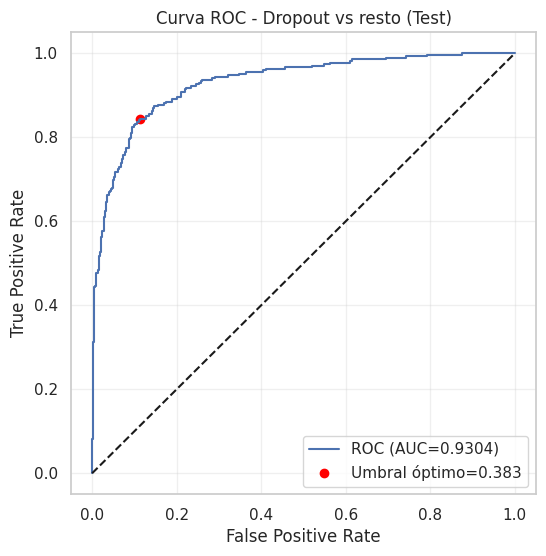


Modelo: RF

--- Clasificación multiclase (3 clases) ---
              precision    recall  f1-score   support

           0       0.83      0.78      0.80       269
           1       0.53      0.36      0.43       153
           2       0.81      0.94      0.87       427

    accuracy                           0.78       849
   macro avg       0.73      0.69      0.70       849
weighted avg       0.77      0.78      0.77       849

=== Resultados binarios (Dropout vs resto) - Umbral 0.50 ===
Accuracy:      0.8740
Sensibilidad:  0.7212
Especificidad: 0.9448
AUC:           0.9333

--- Calibración Youden J ---
Umbral óptimo:        0.3250
Sensibilidad óptima:  0.8625
Especificidad óptima: 0.8690

=== Resultados binarios - Umbral óptimo ===
Accuracy:      0.8669
Sensibilidad:  0.8625
Especificidad: 0.8690


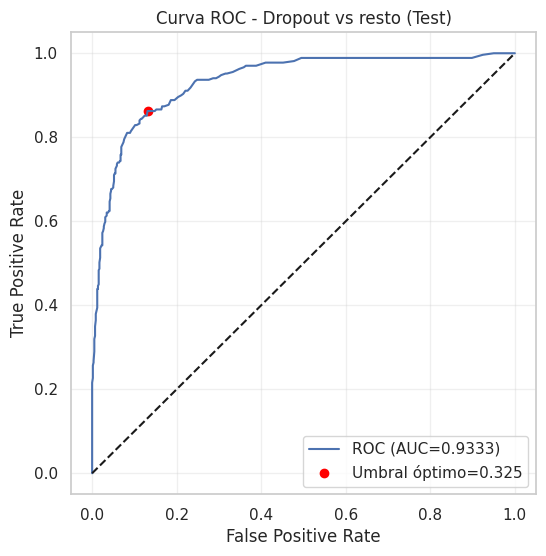


Modelo: XGB

--- Clasificación multiclase (3 clases) ---
              precision    recall  f1-score   support

           0       0.80      0.77      0.78       269
           1       0.48      0.38      0.42       153
           2       0.83      0.91      0.87       427

    accuracy                           0.77       849
   macro avg       0.70      0.69      0.69       849
weighted avg       0.76      0.77      0.76       849

=== Resultados binarios (Dropout vs resto) - Umbral 0.50 ===
Accuracy:      0.8645
Sensibilidad:  0.7546
Especificidad: 0.9155
AUC:           0.9243

--- Calibración Youden J ---
Umbral óptimo:        0.1529
Sensibilidad óptima:  0.8625
Especificidad óptima: 0.8397

=== Resultados binarios - Umbral óptimo ===
Accuracy:      0.8469
Sensibilidad:  0.8625
Especificidad: 0.8397


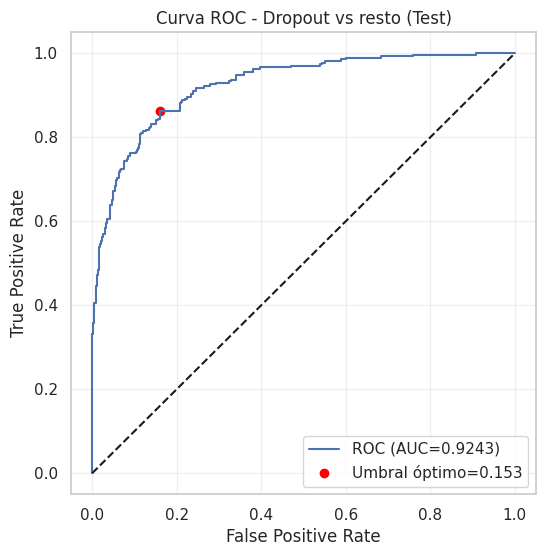


Modelo: SVM

--- Clasificación multiclase (3 clases) ---
              precision    recall  f1-score   support

           0       0.80      0.77      0.78       269
           1       0.50      0.37      0.42       153
           2       0.82      0.93      0.87       427

    accuracy                           0.77       849
   macro avg       0.71      0.69      0.69       849
weighted avg       0.76      0.77      0.76       849

=== Resultados binarios (Dropout vs resto) - Umbral 0.50 ===
Accuracy:      0.8669
Sensibilidad:  0.7584
Especificidad: 0.9172
AUC:           0.9318

--- Calibración Youden J ---
Umbral óptimo:        0.3716
Sensibilidad óptima:  0.8550
Especificidad óptima: 0.8879

=== Resultados binarios - Umbral óptimo ===
Accuracy:      0.8775
Sensibilidad:  0.8550
Especificidad: 0.8879


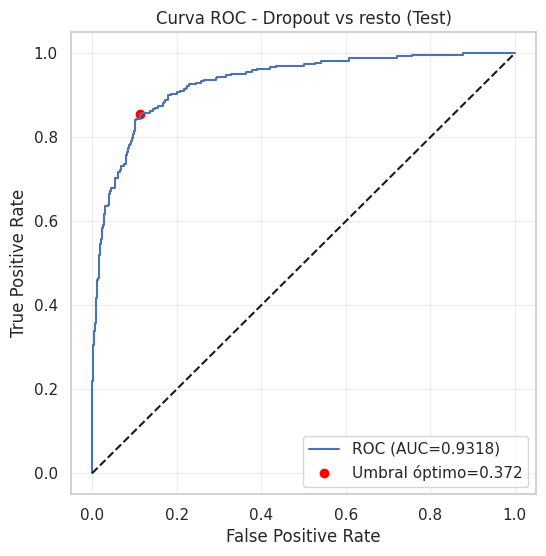

In [217]:
for name, model in best_models.items():
    print("\n" + "="*70)
    print(f"Modelo: {name}")
    print("="*70)
    
    # Primero, reporte multiclase normal
    y_pred_mc = model.predict(X_test)
    print("\n--- Clasificación multiclase (3 clases) ---")
    print(classification_report(y_test, y_pred_mc))
    
    # Luego, evaluación binaria Dropout vs resto con ROC + Youden
    evaluar_dropout_binario(model, X_test, y_test)

In [220]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve
)
import numpy as np
import pandas as pd


def youden_threshold_multiclass(y_true, y_proba, classes):
    """
    Calcula el umbral óptimo (Youden J) para cada clase en configuración OvR.
    Retorna un dict {clase: umbral_optimo} y un promedio para resumen.
    """
    thresholds_by_class = {}

    for i, cls in enumerate(classes):
        fpr, tpr, thr = roc_curve((y_true == cls).astype(int), y_proba[:, i])

        youden = tpr - fpr
        best_thr = thr[np.argmax(youden)]
        thresholds_by_class[cls] = best_thr

    # Para resumen estilo tabla:
    avg_thr = np.mean(list(thresholds_by_class.values()))
    return thresholds_by_class, avg_thr


def results_multiclass(model, X_train, X_test, y_train, y_test, model_name):
    """
    Genera métricas para Train/Test + umbrales óptimos multiclase.
    """
    # Probabilidades
    proba_train = model.predict_proba(X_train)
    proba_test  = model.predict_proba(X_test)

    # Predicciones base (sin umbral especial)
    pred_train = model.predict(X_train)
    pred_test  = model.predict(X_test)

    classes = model.classes_

    # Métricas básicas
    def compute_metrics(y_true, pred, proba):
        acc = accuracy_score(y_true, pred)
        f1_macro = f1_score(y_true, pred, average="macro")
        auc_macro = roc_auc_score(y_true, proba, multi_class="ovr")
        return acc, f1_macro, auc_macro

    acc_tr, f1_tr, auc_tr = compute_metrics(y_train, pred_train, proba_train)
    acc_te, f1_te, auc_te = compute_metrics(y_test, pred_test, proba_test)

    # Umbrales óptimos (OvR)
    thr_train_dict, thr_train_avg = youden_threshold_multiclass(y_train, proba_train, classes)
    thr_test_dict,  thr_test_avg  = youden_threshold_multiclass(y_test,  proba_test,  classes)

    # Armar el diccionario resumen estilo la tabla anterior
    summary = {
        "Model": model_name,
        "Accuracy Train": acc_tr,
        "Accuracy Test": acc_te,
        "F1 Train": f1_tr,
        "F1 Test": f1_te,
        "AUC Train": auc_tr,
        "AUC Test": auc_te,
        "Best Thr Train (avg)": thr_train_avg,
        "Best Thr Test (avg)": thr_test_avg,
        "Thr per class Train": thr_train_dict,
        "Thr per class Test": thr_test_dict
    }

    return summary


def summarize_models(models_info, X_train, X_test, y_train, y_test):
    """
    models_info = [("LogReg", logreg_best), ("RandomForest", rf_best), ...]
    """
    results = []

    for name, model in models_info:
        print(f"\n=== Evaluando modelo: {name} ===")
        res = results_multiclass(model, X_train, X_test, y_train, y_test, name)
        results.append(res)

    # Convertir a DataFrame para presentar
    df = pd.DataFrame(results)
    return df


In [228]:
models_info = [
    ("LogReg", best_models['LogReg']),
    ("RandomForest", best_models['RF']),
    ("XGBoost", best_models['XGB']),
    ("SVM", best_models['SVM'])
]

In [229]:
df_resumen = summarize_models(models_info, X_train, X_test, y_train, y_test)
df_resumen


=== Evaluando modelo: LogReg ===

=== Evaluando modelo: RandomForest ===

=== Evaluando modelo: XGBoost ===

=== Evaluando modelo: SVM ===


,Model,Accuracy Train,Accuracy Test,F1 Train,F1 Test,AUC Train,AUC Test,Best Thr Train (avg),Best Thr Test (avg),Thr per class Train,Thr per class Test
0,LogReg,0.801767,0.782097,0.732518,0.697568,0.909771,0.888783,0.341428,0.302186,"{0: 0.33488008643926864, 1: 0.1786318461655633...","{0: 0.382818014135514, 1: 0.19366092627681472,..."
1,RandomForest,1.000000,0.783274,1.000000,0.700928,1.000000,0.886795,0.581667,0.328333,"{0: 0.555, 1: 0.565, 2: 0.625}","{0: 0.325, 1: 0.195, 2: 0.465}"
2,XGBoost,1.000000,0.769140,1.000000,0.691021,1.000000,0.885389,0.760360,0.263480,"{0: 0.736977, 1: 0.7068206, 2: 0.8372816}","{0: 0.15289357, 1: 0.028466942, 2: 0.6090781}"
3,SVM,0.855965,0.773852,0.810746,0.692096,0.947046,0.893468,0.354460,0.374351,"{0: 0.32074494595048336, 1: 0.2026597781543238...","{0: 0.3715786863558864, 1: 0.20907523033864128..."
